<a href="https://colab.research.google.com/github/Samuelameningayeh/thesis/blob/main/synthetic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
# import cmdstanpy
# cmdstanpy.install_cmdstan()


In [27]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
from cmdstanpy import CmdStanModel, cmdstan_path
import arviz as az
from pathlib import Path

from loadData import load_data
from imputeMissing import impute_value

from scipy.integrate import odeint

import logging
cmdstanpy_logger = logging.getLogger("cmdstanpy")
cmdstanpy_logger.disabled = True

# Define the SEIR model

$$ 
\begin{aligned}
\frac{dS_p}{dt} &= -\beta_p S_p \frac{I_p}{N_p}\\

\frac{dE_p}{dt} &= \beta_p S_p \frac{I_p}{N_p} - \sigma_p E_p \\

\frac{dI_p}{dt} &= \sigma_p E_p - \gamma_p I_p \\

\frac{dR_p}{dt} &= \gamma_p I_p
\end{aligned}
$$

Where:
- $ S_p, E_p, I_p, R_p $: Susceptible, Exposed, Infectious, and Recovered individuals in patch $ p $.
- $ N_p $: Total population for patch $ p $.
- $ \beta_p $: Transmission rate in patch $ p $.
- $ \sigma_p $: Rate of progression from Exposed to Infectious (inverse of the latent period).
- $ \gamma_p $: Recovery rate (inverse of the infectious period).

In [28]:
# ---- SEIR ODE system --------------------------------------------------------
def seir(state, t, beta, sigma, gamma, alpha, N):
    n=len(N)
    S = state[:n]
    E = state[n:2*n]
    I = state[2*n:3*n]
    R = state[3*n:4*n]
    D = state[4*n:5*n]
    C = state[5*n:]

    dS = np.zeros(n)
    dE = np.zeros(n)
    dI = np.zeros(n)
    dR = np.zeros(n)
    dD = np.zeros(n)
    dC = np.zeros(n)
    
    for i in range(n):
        dS[i] = -beta[i] * S[i] * I[i] / N[i]
        dE[i] =  beta[i] * S[i] * I[i] / N[i] - sigma * E[i]
        dI[i] =  sigma * E[i] - (gamma + alpha) * I[i]
        dR[i] =  gamma * I[i]
        dD[i] = alpha * I[i]
        dC[i] = sigma * E[i]
    
    return np.concatenate([dS.flatten(), dE.flatten(), dI.flatten(), dR.flatten(), dD.flatten(), dC.flatten()])


# Define Parameters

In [29]:
1/8.5 *7 

0.8235294117647058

In [30]:
n_regions = 3 
T = 96 #679/7
# Time vector
t = np.linspace(0, T, T)

# N = [11.5e6, 4.5e6, 6.8e6]  # Guinea, Liberia, Sierra Leone
# N=[1000000, 960000, 745000]
N = np.array([110000, 440000, 680000])

## Get the Parameters
beta = np.array([0.3, 0.4, 0.35])*7  # Transmission rate (R0 = beta/gamma)
sigma = 1/8.5 *7       # 1/latent period (Ebola: ~10 days) Average value
gamma = 1/13 *7      # 1/infectious period (Ebola: ~7 days)
phi = 10           # Negative binomial dispersion parameter
alpha = 0.05*7
reporting_rate = 1 #0.8  # Proportion of cases reported

## Get initials
# guinea = [N[0]-1000, 0, 1000, 0, 1000]
# lib = [N[1]-100, 0, 100, 0, 100]
# sir = [N[2]-100, 0, 100, 0, 100]

# Initial conditions
E0 = np.array([10, 10, 10])
I0 = np.array([10, 10, 10])
R0 = np.array([0,0,0])
D0 = np.array([0,0,0])
C0 = np.array([0,0,0])
S0 = np.array([N[0]-10, N[1]-10, N[2]-10])

# initial_state = [guinea, lib, sir]
y0 = np.concatenate([S0.flatten(), E0.flatten(), I0.flatten(), R0.flatten(), D0.flatten(), C0.flatten()])


# Solve the ODEs

In [31]:
# Simulate SEIR for each region
sol = odeint(seir, y0, t, args=(beta, sigma, gamma,alpha, N))

## Get the New Infections and Deaths

In [32]:
n = 3
# Extract and aggregate results
# S = sol[:, :n]
# E = sol[:, n:2*n]
# I = sol[:, 2*n:3*n]
# R = sol[:, 3*n:4*n]
# D = sol[:, 4*n:]

## Total per patch (sum over resident patches i)
S_total = sol[:, :n]
E_total = sol[:, n:2*n]
I_total = sol[:, 2*n:3*n]
R_total = sol[:, 3*n:4*n]
D_total = sol[:, 4*n:5*n]
C_total = sol[:, 5*n:]


## get the new infected individuals at each time
Infections = np.zeros([T, n])
Deaths = np.zeros([T, n])

for j in range(3):
    ## get new infections
    for i in (range(len(C_total))):

        if (i+1 == len(C_total)):
            new_infections = [0.0,0.0,0.0]
            Infections[i, j] = new_infections[j]
        else:
            new_infections = C_total[i+1] - C_total[i]
            Infections[i+1, j] = new_infections[j]
    
    ## get new deaths
    for i in (range(len(D_total))):

        if (i+1 == len(D_total)):
            new_deaths = [0.0,0.0,0.0]
            Deaths[i, j] = new_deaths[j]
        else:
            new_deaths = D_total[i+1] - D_total[i]
            Deaths[i+1, j] = new_deaths[j]

## Show New infections

In [33]:
Infections[:100]

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.28323595e+01, 1.56123126e+01, 1.41974855e+01],
       [2.19574638e+01, 3.30422897e+01, 2.71525094e+01],
       [3.50871034e+01, 6.47774992e+01, 4.82472635e+01],
       [5.57896188e+01, 1.26529159e+02, 8.53806032e+01],
       [8.86238686e+01, 2.46985044e+02, 1.51031447e+02],
       [1.40640477e+02, 4.81639582e+02, 2.67071434e+02],
       [2.22838683e+02, 9.37442726e+02, 4.71992520e+02],
       [3.52205769e+02, 1.81784409e+03, 8.33292537e+02],
       [5.54506832e+02, 3.49988962e+03, 1.46850117e+03],
       [8.67669634e+02, 6.64645342e+03, 2.57969552e+03],
       [1.34477751e+03, 1.23004769e+04, 4.50649732e+03],
       [2.05375582e+03, 2.17225343e+04, 7.79637106e+03],
       [3.06732915e+03, 3.54089744e+04, 1.32647193e+04],
       [4.43288709e+03, 5.09737867e+04, 2.19436357e+04],
       [6.11413419e+03, 6.20630264e+04, 3.46820298e+04],
       [7.91919341e+03, 6.25395622e+04, 5.11012454e+04],
       [9.47814360e+03, 5.28198

In [34]:
Deaths

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [3.88941469e+00, 4.15110575e+00, 4.01869441e+00],
       [5.76448369e+00, 7.51229851e+00, 6.59955359e+00],
       [9.12062506e+00, 1.46219510e+01, 1.16264957e+01],
       [1.44957259e+01, 2.85557521e+01, 2.05661327e+01],
       [2.30356422e+01, 5.57571445e+01, 3.63831814e+01],
       [3.65806648e+01, 1.08795931e+02, 6.43504839e+01],
       [5.80225679e+01, 2.12003909e+02, 1.13768420e+02],
       [9.18628466e+01, 4.12045432e+02, 2.00988333e+02],
       [1.45015787e+02, 7.96817391e+02, 3.54612298e+02],
       [2.27875071e+02, 1.52606933e+03, 6.24222764e+02],
       [3.55518933e+02, 2.86988186e+03, 1.09439901e+03],
       [5.48541853e+02, 5.21960579e+03, 1.90528953e+03],
       [8.32183746e+02, 8.95782423e+03, 3.27706658e+03],
       [1.23115932e+03, 1.40155720e+04, 5.52211560e+03],
       [1.75677054e+03, 1.92558210e+04, 8.99735998e+03],
       [2.38551928e+03, 2.26250230e+04, 1.39089187e+04],
       [3.03853099e+03, 2.26602

## Add Noise

In [35]:
## Function to add noise
def Add_noise(data, reporting_rate):
    observed_cases = []
    for i in range(len(np.array(data))):
        case = []
        for t in range(len(np.array(data)[i])):
            mean_cases = reporting_rate * np.array(data)[i][t]

            # Negative binomial: r = phi (dispersion), p = phi/(phi + mean)
            p = phi / (phi + mean_cases)
            case.append(np.random.negative_binomial(phi, p))
        observed_cases.append(case)
    return np.array(observed_cases)


In [36]:
observed_cases = Add_noise(Infections, reporting_rate= reporting_rate)
observed_deaths = Add_noise(Deaths, reporting_rate= reporting_rate)
c = pd.DataFrame(observed_cases, columns = ['Guinea', 'Liberia', 'Sierra Leone'])
d = pd.DataFrame(observed_deaths, columns = ['Guinea', 'Liberia', 'Sierra Leone'])


## Create a dataframe

In [37]:
# Create dataset
data = {
    'time': pd.date_range(start='2013-12-28', periods=T, freq='D'),
    'Day': t.astype(int),
    'S_Guinea': S_total[:, 0],
    'E_Guinea': E_total[:, 0],
    'I_Guinea': I_total[:, 0],
    'R_Guinea': R_total[:, 0],
    'D_Guinea': D_total[:, 0],
    'C_Guinea': C_total[:, 0],
    'Guinea_New_case': Infections[:, 0],
    'Guinea_Noise' : c['Guinea'],
    'Guinea_New_Deaths': Deaths[:, 0],
    'Guinea_Death_Noise' : d['Guinea'],

    'S_Liberia': S_total[:, 1],
    'E_Liberia': E_total[:, 1],
    'I_Liberia': I_total[:, 1],
    'R_Liberia': R_total[:, 1],
    'D_Liberia': D_total[:, 1],
    'C_Liberia': C_total[:, 1],
    'Liberia_New_case': Infections[:, 1],
    'Liberia_Noise' : c['Liberia'],
    'Liberia_New_Deaths': Deaths[:, 1],
    'Liberia_Death_Noise' : d['Liberia'],

    'S_SierraLeone': S_total[:, 2],
    'E_SierraLeone': E_total[:, 2],
    'I_SierraLeone': I_total[:, 2],
    'R_SierraLeone': R_total[:, 2],
    'D_SierraLeone': D_total[:, 2],
    'C_SierraLeone': C_total[:, 2],
    'SierraLeone_New_case': Infections[:, 2],
    'SierraLeone_Noise' : c['Sierra Leone'],
    'SierraLeone_New_Deaths': Deaths[:, 2],
    'SierraLeone_Death_Noise' : d['Sierra Leone'],
}

raw = pd.DataFrame(data)
# df.to_csv('synthetic_ebola_dataset_with_death.csv', index=False)
raw.head()

,time,Day,S_Guinea,E_Guinea,I_Guinea,R_Guinea,D_Guinea,C_Guinea,Guinea_New_case,Guinea_Noise,...,S_SierraLeone,E_SierraLeone,I_SierraLeone,R_SierraLeone,D_SierraLeone,C_SierraLeone,SierraLeone_New_case,SierraLeone_Noise,SierraLeone_New_Deaths,SierraLeone_Death_Noise
0,2013-12-28,0,109990.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0,...,679990.000000,10.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0
1,2013-12-29,1,109966.668108,20.499532,12.959230,5.983715,3.889415,12.832360,12.832360,12,...,679961.870135,23.932380,13.996184,6.182607,4.018694,14.197485,14.197485,7,4.018694,0
2,2013-12-30,2,109932.097122,33.113055,20.283774,14.852151,9.653898,34.789823,21.957464,24,...,679915.677419,42.972586,24.395981,16.335766,10.618248,41.349995,27.152509,51,6.599554,10
3,2013-12-31,3,109877.420754,52.702319,32.218521,28.883882,18.774523,69.876927,35.087103,39,...,679834.306910,76.095831,43.129832,34.222683,22.244744,89.597258,48.247263,45,11.626496,18
4,2014-01-01,4,109790.577656,83.755798,51.211297,51.184999,33.270249,125.666546,55.789619,39,...,679690.394295,134.627843,76.304098,65.862887,42.810876,174.977862,85.380603,82,20.566133,29


# Plot the results

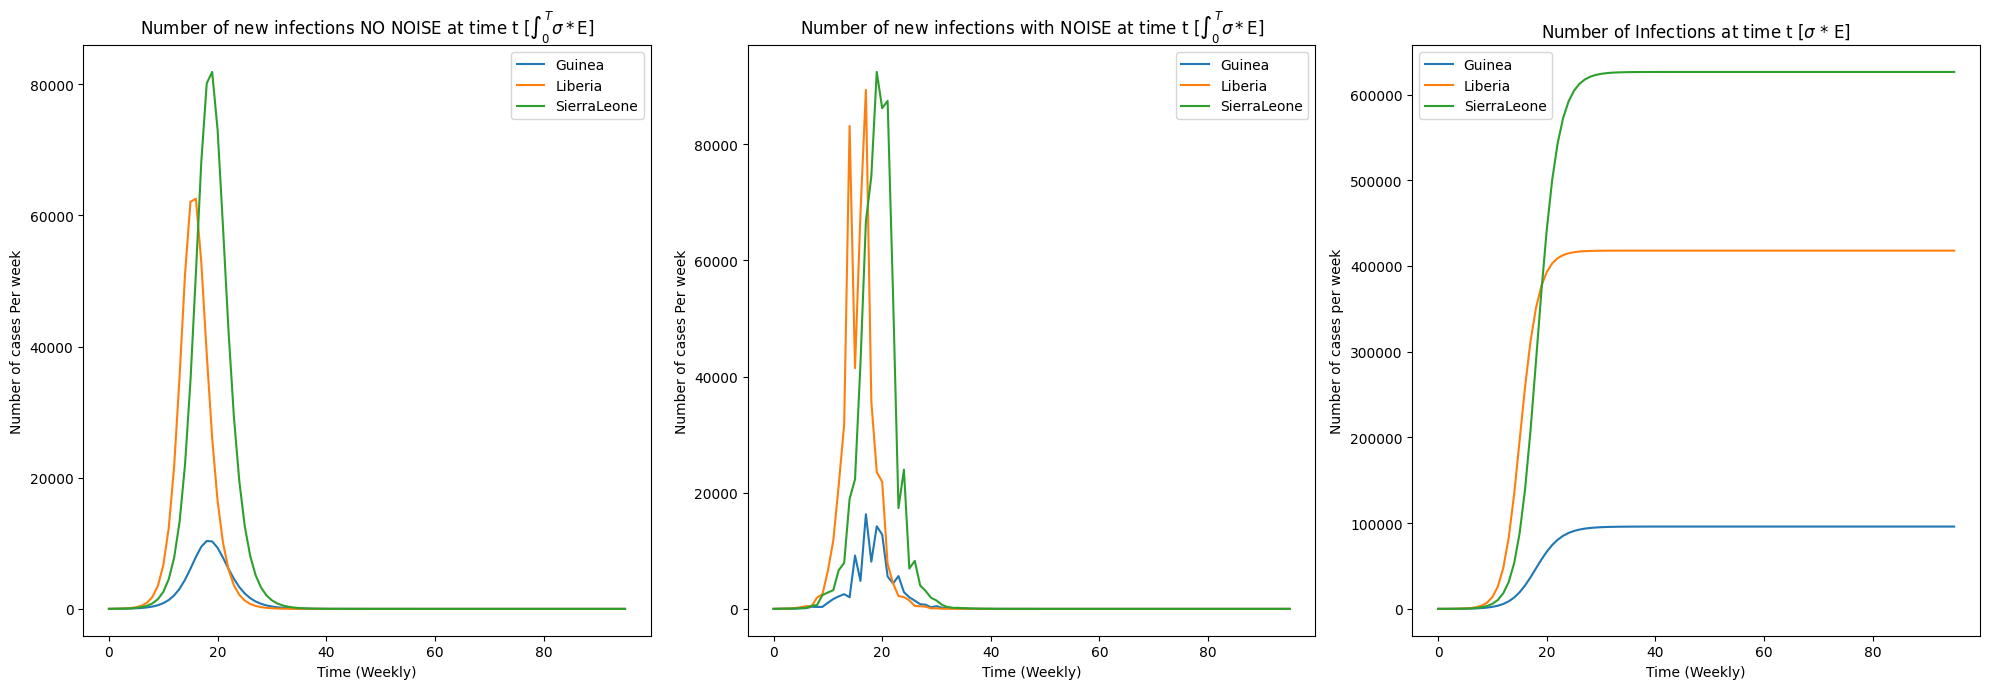

In [38]:
fig, ax = plt.subplots(1,3, figsize = (20,7))
countries = ['Guinea', 'Liberia', 'SierraLeone']
for i in range(3):
    ax[0].plot(raw[f'{countries[i]}_New_case'])
    ax[0].legend(countries)
    ax[0].set_title('Number of new infections NO NOISE at time t $[\int_0^T \sigma*$E]')
    ax[0].set_xlabel('Time (Weekly)')
    ax[0].set_ylabel('Number of cases Per week')

    ax[1].plot(raw[f'{countries[i]}_Noise'])
    ax[1].legend(countries)
    ax[1].set_title('Number of new infections with NOISE at time t $[\int_0^T \sigma*$E]')
    ax[1].set_xlabel('Time (Weekly)')
    ax[1].set_ylabel('Number of cases Per week')

    ax[2].plot(raw[f'C_{countries[i]}'])
    ax[2].legend(countries)
    ax[2].set_title('Number of Infections at time t [$ \sigma$ * E]')
    ax[2].set_xlabel('Time (Weekly)')
    ax[2].set_ylabel('Number of cases per week')

plt.tight_layout()
plt.show()

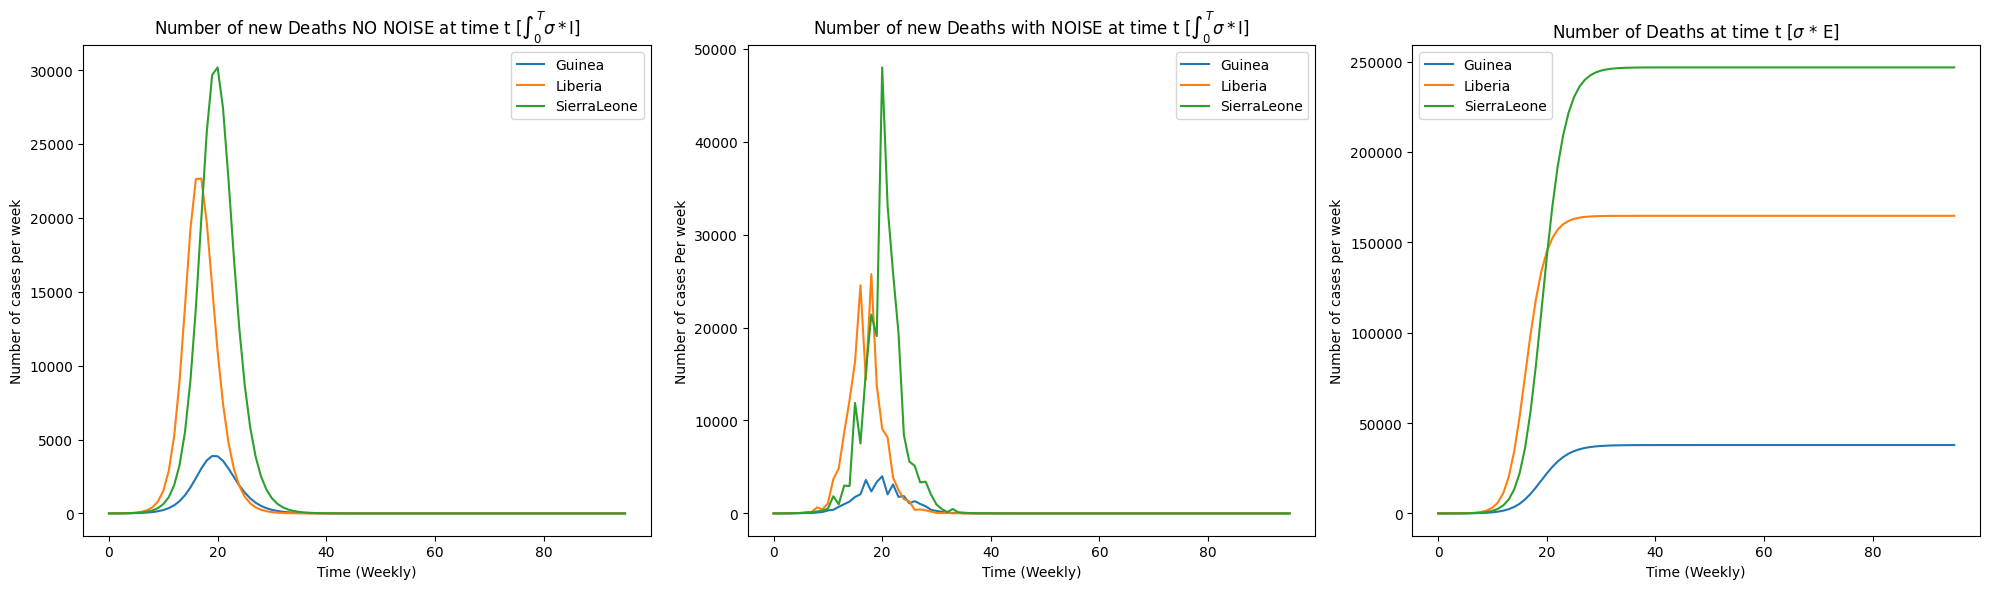

In [39]:
fig, ax = plt.subplots(1,3, figsize = (20,6))
countries = ['Guinea', 'Liberia', 'SierraLeone']
for i in range(3):
    ax[0].plot(raw[f'{countries[i]}_New_Deaths'])
    ax[0].legend(countries)
    ax[0].set_title('Number of new Deaths NO NOISE at time t $[\int_0^T \sigma*$I]')
    ax[0].set_xlabel('Time (Weekly)')
    ax[0].set_ylabel('Number of cases per week')

    ax[1].plot(raw[f'{countries[i]}_Death_Noise'])
    ax[1].legend(countries)
    ax[1].set_title('Number of new Deaths with NOISE at time t $[\int_0^T \sigma*$I]')
    ax[1].set_xlabel('Time (Weekly)')
    ax[1].set_ylabel('Number of cases Per week')

    ax[2].plot(raw[f'D_{countries[i]}'])
    ax[2].legend(countries)
    ax[2].set_title('Number of Deaths at time t [$ \sigma$ * E]')
    ax[2].set_xlabel('Time (Weekly)')
    ax[2].set_ylabel('Number of cases per week')

plt.tight_layout()
plt.show()

In [40]:
# Plot for each country
countries = ['Guinea', 'Liberia', 'SierraLeone']
def plot_SEIR(df, country_name, Death = False, save=False, yscale = True):
    # Extract data for the current country
    S = df[f'S_{country_name}']
    E = df[f'E_{country_name}']
    I = df[f'I_{country_name}']
    R = df[f'R_{country_name}']

    # Create plot
    plt.figure(figsize=(13, 6))
    plt.plot(df['Day'], S, label='Susceptible', color='blue')
    plt.plot(df['Day'], E, label='Exposed', color='orange')
    plt.plot(df['Day'], I, label='Infective', color='red')
    plt.plot(df['Day'], R, label='Recovered', color='green')
    if Death:
        D = df[f'D_{country_name}']
        plt.plot(df['Day'], D, label='Death', color='black')

    # Customize the plot
    plt.xlabel('Day')
    plt.ylabel('Number of Individuals')
    plt.title(f'SEIRD Dynamics for {country_name}')
    plt.legend()
    plt.grid(True)
    if yscale:
        plt.yscale('symlog')  # Use symlog scale to handle large ranges
    if save:
        plt.savefig(f'seird_{country_name.lower()}.png')
    plt.show()

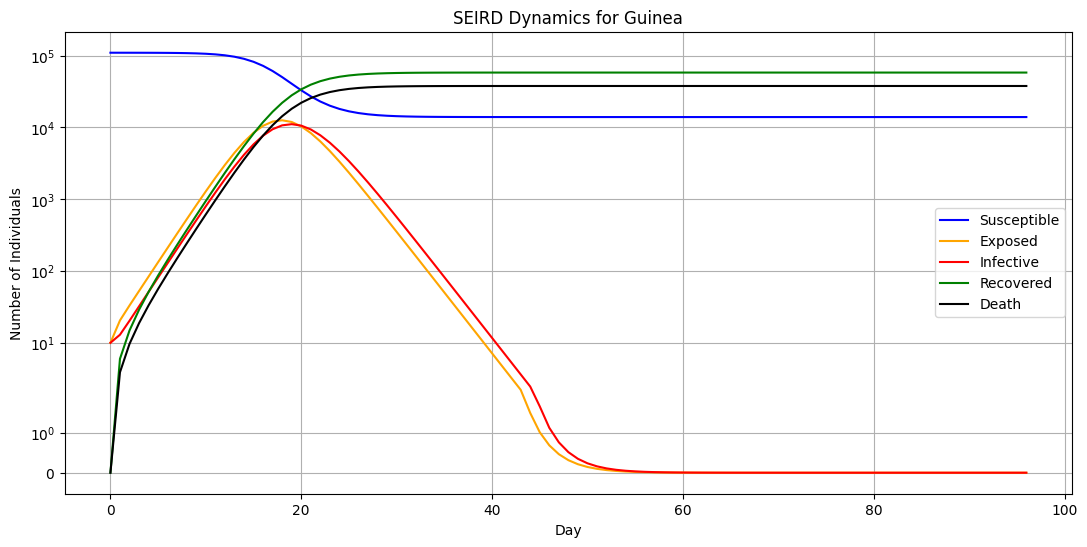

In [41]:
plot_SEIR(raw, 'Guinea', Death=True)

# Aggregate the Data from daily cases to weekly cases

## Aggregate the Data

In [42]:
# def Aggregate_data(data):
#     # Convert the 'time' column to datetime format, assuming it represents days since 2014-01-01
#     # data["time"] = pd.Timestamp("2014-01-01") + pd.to_timedelta(data["time"], unit="D")

#     ## get patches
#     patch_names = ["Guinea", "Liberia", "Sierra Leone"]
#     n_patches = len(patch_names)

#     ## Set the start date and end of the date
#     start_date =  data["time"].min()
#     end_date = data["time"].max()
#     weeks = pd.date_range(start=start_date, end=end_date, freq="W-MON")
#     T = len(weeks)

#     ## Create an empty array to store observed cases
#     I_obs = np.zeros((T, n_patches))

#     ## Fill the observed cases array with weekly data for each patch
#     for i, country in enumerate(patch_names):
#         country_data = data[data["country"] == country]
#         weekly_cases = country_data.groupby(pd.Grouper(key="time", freq="W-MON"))['cases'].sum()
#         # weekly_cases.index = pd.to_datetime(weekly_cases.index)
#         weekly_cases = weekly_cases.reindex(weeks, fill_value=0)
#         I_obs[:, i] = weekly_cases.values

#     ## Create a DataFrame for plotting
#     time = np.arange(1, T + 1)
#     Cases = pd.DataFrame(I_obs, columns=patch_names)
#     Cases["Time"] = time
#     Cases["Week"] = weeks[:].strftime("%Y-%m-%d")

#     # Melt the DataFrame for easier plotting
#     Cases = Cases.melt(id_vars=["Time", "Week"], var_name="Patches", value_name="Cases")

#     return Cases

In [43]:
# df2 = raw[['time','Guinea_New_case', 'Liberia_New_case', 'SierraLeone_New_case']]
# # weekly_cases = df2.groupby(pd.Grouper(key="time", freq="W-MON"))[['Guinea_New_case', 'Liberia_New_case', 'SierraLeone_New_case']].sum()

## Add the noise to the data

In [44]:
def add_nb_noise(series, dispersion=10):
    # Ensure the series contains only numeric values
    series = pd.to_numeric(series, errors='coerce')  # Convert non-numeric to NaN
    series = series.fillna(0)  # Replace NaN with 0 (or handle it as needed)

    mu = series.values
    r = dispersion
    p = r / (r + mu)  # NB2 parameterization

    noisy = np.random.negative_binomial(n=r, p=p)
    return pd.Series(noisy, index=series.index)


In [45]:
# weekly_cases = weekly_cases.reset_index(drop=True)

# # Apply to all three columns
# noisy_cases = weekly_cases.copy()
# for col in noisy_cases.columns:
#     noisy_cases[col] = add_nb_noise(noisy_cases[col], dispersion=10)

# noisy_cases.head()

## Plot them

In [46]:
# fig, ax = plt.subplots(1, 2, figsize=(18, 7))
# ct =['Guinea_New_case', 'Liberia_New_case', 'SierraLeone_New_case']

# # Plot each patch separately
# for patch in ct:
#     ax[0].plot(raw['Day'], raw[patch], label=patch)
# ax[0].set_title("Weekly New Ebola Cases (Noised Before Aggregation)")
# ax[0].set_xlabel("Week")
# ax[0].set_ylabel("Number of Cases")
# ax[0].legend(title="Patches")

# for patch in ct:
#     ax[1].plot(noisy_cases.index, noisy_cases[patch], label=patch)
# ax[1].set_title("Weekly New Ebola Cases  (Noised After aggregation)")
# ax[1].set_xlabel("Week")
# ax[1].set_ylabel("Number of Cases")
# ax[1].legend(title="Patches")
# # plt.grid(True)
# # plt.savefig('./images/weekly_cases.pdf', bbox_inches='tight')
# plt.show()

# Create a function to plot Posterior for Parameters

In [47]:
import math

def plot_posterior_kde_grid(fit:any, parameters: list, n_cols: int, true_values: dict = None, save:str = None):
    """
    Plot KDEs of posterior samples for given parameters from a CmdStanMCMC fit.

    Args:
        fit (CmdStanMCMC): The fitted model.
        parameters (list of str): Names of parameters to plot.
        n_rows (int): Number of subplot rows.
        n_cols (int): Number of subplot columns.
        true_values (dict, optional): Dict mapping param names to true values for reference lines.
    """
    posterior_samples = fit.draws_pd()
    
    # Dynamically calculate the number of rows
    n_params = len(parameters)
    n_rows = math.ceil(n_params / n_cols)

    fig, ax = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4 * n_rows))
    ax = ax.flatten()  # flatten axes for easy indexing

    for i, param in enumerate(parameters):
        if param in posterior_samples.columns:
            sns.kdeplot(posterior_samples[param], fill=True, ax=ax[i])
            if true_values and param in true_values:
                ax[i].axvline(x=true_values[param], color='r', linestyle='--', label='True value')
                ax[i].legend()
            ax[i].set_xlabel(param)
            ax[i].set_ylabel('Density')
            ax[i].set_title(f'Posterior of {param}')
        else:
            ax[i].text(0.5, 0.5, f"{param} not found", ha='center', va='center')
            ax[i].axis('off')

    # Hide unused axes
    for j in range(len(parameters), len(ax)):
        ax[j].axis('off')

    plt.tight_layout()
    if save:
        plt.savefig(f'./images/{save}.pdf', bbox_inches='tight')
    plt.show()


# Fit the Model to daily cases


In [48]:
# Aggregate cases by country and week
countries = ['Guinea', 'Liberia', 'Sierra Leone']
# weekly_cases = df.groupby(['country', pd.Grouper(key='time', freq='W')]).sum().unstack(fill_value=0).T
weekly_cases1 = raw['Guinea_Noise']
weekly_cases2 = raw['Liberia_Noise']
weekly_cases3 = raw['SierraLeone_Noise']

cases1 = weekly_cases1.values  # Shape: (T, 3)
cases2 = weekly_cases2.values  # Shape: (T, 3)
cases3 = weekly_cases3.values  # Shape: (T, 3)

N = np.array([11.5e6, 4.5e6, 6.8e6]) 
# N = np.array([110000, 440000, 680000]) 
# N=np.array([2e6, 1.5e6, 1e6])
# Set the population size
# N = n[0] #763

beta = np.array([0.3, 0.4, 0.35])*7  # Transmission rate (R0 = beta/gamma)
sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7
gamma = np.array([1/13, 1/14, 1/13])*7
phi = 10           # Negative binomial dispersion parameter
alpha = 0.05*7
reporting_rate = 1 

# Define initial conditions
i0 = [10, 10, 10]
e0 = [10, 1, 1]
s0 = N - i0
r0 = [0, 0, 0]
c0 = [0, 0, 0]
y1 = [s0[0], e0[0], i0[0], r0[0], c0[0]]
y2 = [s0[1], e0[1], i0[1], r0[1], c0[1]]
y3 = [s0[2], e0[2], i0[2], r0[2], c0[2]]


In [24]:

# Make the data struture
seir_data1 = {
    "n_days": len(cases1),
    "y0": y1,
    "t0": 0,
    "t": np.arange(1, len(cases1)+1),
    "N": int(N[0]),
    "cases": cases1,
    'beta_value': beta[0],
    'sigma_value': sigma[0],
    'gamma_value': gamma[0],
    "reporting_rate": reporting_rate
}

seir_data2 = {
    "n_days": len(cases2),
    "y0": y2,
    "t0": 0,
    "t": np.arange(1, len(cases2)+1),
    "N": int(N[1]),
    "cases": cases2,
    'beta_value': beta[1],
    'sigma_value': sigma[1],
    'gamma_value': gamma[1],
    "reporting_rate": reporting_rate
}
seir_data3 = {
    "n_days": len(cases3),
    "y0": y3,
    "t0": 0,
    "t": np.arange(1, len(cases3)+1),
    "N": int(N[2]),
    "cases": cases3,
    'beta_value': beta[2],
    'sigma_value': sigma[2],
    'gamma_value': gamma[2],
    "reporting_rate": reporting_rate
}

seir_incidence_model = CmdStanModel(stan_file = 'stan files/guinea.stan')
seir_incidence_model1 = CmdStanModel(stan_file = 'stan files/lib.stan')
seir_incidence_model2 = CmdStanModel(stan_file = 'stan files/sierra.stan')

In [28]:
fit_seir_incidence_model = seir_incidence_model.sample(data = seir_data1,
                                                    #    iter_warmup= 500,
                                                       iter_sampling = 1000,
                                                       parallel_chains=True,
                                                       chains = 4,
                                                       seed = 0)

chain 1 |          | 00:00 Status




chain 1 |██████████| 24:22 Iteration: 1900 / 2000 [ 95%]  (Sampling)































































chain 1 |██████████| 1:02:19 Sampling completed                     
chain 2 |██████████| 1:02:19 Sampling completed                     
chain 3 |██████████| 1:02:19 Sampling completed                     
chain 4 |██████████| 1:02:19 Sampling completed                       

In [29]:
fit2 = seir_incidence_model1.sample(data = seir_data2,
                                    iter_warmup= 500,
                                   iter_sampling = 1000,
                                   parallel_chains=True,
                                   chains = 4,
                                   seed = 3)

chain 1 |          | 00:00 Status




chain 1 |██████████| 07:55 Iteration: 1400 / 1500 [ 93%]  (Sampling)















































chain 1 |██████████| 37:57 Sampling completed                       
chain 2 |██████████| 37:57 Sampling completed                       
chain 3 |██████████| 37:57 Sampling completed                       
chain 4 |██████████| 37:57 Sampling completed                       

In [30]:
fit3 = seir_incidence_model2.sample(data = seir_data3,
                                    iter_warmup= 500,
                                   iter_sampling = 1000,
                                   parallel_chains=True,
                                   chains = 4,
                                   seed = 2)

chain 1 |          | 00:00 Status


chain 1 |██████████| 13:24 Iteration: 1400 / 1500 [ 93%]  (Sampling)















































chain 1 |██████████| 51:22 Sampling completed                       
chain 2 |██████████| 51:22 Sampling completed                       
chain 3 |██████████| 51:22 Sampling completed                       
chain 4 |██████████| 51:22 Sampling completed                       

In [31]:
seir_incidence_summary = fit_seir_incidence_model.summary()
seir_incidence_summary.filter(items=("sigma", "beta", "recovery_time", "gamma", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,0.857121,0.002537,0.106194,0.100815,0.703142,0.845881,1.051580,1810.24,2012.62,1.00162
beta,1.969190,0.004339,0.150003,0.144109,1.750390,1.955400,2.231100,1335.63,1532.30,1.00143
recovery_time,1.225130,0.004596,0.161304,0.161485,0.973811,1.218740,1.499890,1225.32,1460.18,1.00391
gamma,0.830725,0.003284,0.112086,0.107479,0.666716,0.820523,1.026890,1225.33,1460.18,1.00391
incubation_period,1.184100,0.003351,0.142581,0.141240,0.950948,1.182200,1.422190,1810.24,2012.62,1.00162
R0,2.393560,0.005368,0.206402,0.199343,2.078560,2.378670,2.760030,1486.35,1826.28,1.00364
phi,7.314730,0.030732,1.467820,1.407770,5.046840,7.210710,9.829880,2272.76,1947.07,1.00193
phi_inv,0.142403,0.000653,0.029645,0.026690,0.101731,0.138682,0.198144,2272.76,1947.07,1.00197


In [32]:
fit2_summary = fit2.summary()
fit2_summary.filter(items=("sigma", "beta", "recovery_time", "gamma", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,0.932161,0.003021,0.130156,0.123403,0.752394,0.915853,1.173070,1930.33,2023.55,1.00229
beta,2.589490,0.005270,0.208390,0.193894,2.282270,2.570880,2.967450,1688.00,1281.40,1.00035
recovery_time,1.193210,0.004056,0.162330,0.163523,0.934992,1.188800,1.459020,1604.36,1452.25,1.00031
gamma,0.854309,0.003177,0.122034,0.112722,0.685392,0.841185,1.069530,1604.35,1452.25,1.00031
incubation_period,1.092750,0.003324,0.145695,0.148088,0.852459,1.091870,1.329090,1930.32,2023.55,1.00231
R0,3.068860,0.007973,0.332329,0.333007,2.571760,3.046340,3.646480,1749.54,1838.37,1.00031
phi,6.475730,0.035264,1.699670,1.652190,4.015610,6.293940,9.527530,2330.24,2051.63,1.00004
phi_inv,0.165546,0.000981,0.045425,0.041129,0.104959,0.158883,0.249028,2330.22,2051.63,1.00004


In [33]:
fit3_summary = fit3.summary()
fit3_summary.filter(items=("sigma", "beta", "recovery_time", "gamma", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,0.786118,0.137684,0.225364,0.192624,0.451116,0.819846,1.130220,7.21802,2000.00,1.53142
beta,2.097710,0.178510,0.304231,0.295171,1.630830,2.126170,2.587820,7.24172,2000.00,1.53215
recovery_time,3.012230,2.115260,3.018520,0.276935,1.012870,1.364100,8.820080,7.23564,2000.00,1.52937
gamma,0.625672,0.207251,0.307003,0.157986,0.113378,0.733081,0.987294,7.23563,2000.00,1.52950
incubation_period,1.402560,0.320542,0.473050,0.269211,0.884787,1.219740,2.216720,7.21804,2000.00,1.53142
R0,5.564590,3.320490,4.730060,0.473846,2.441790,2.967140,14.511900,7.30200,2000.00,1.52944
phi,7.870260,0.323758,1.775410,1.756970,5.194180,7.742910,11.059700,63.09880,1605.11,1.05143
phi_inv,0.133860,0.006419,0.031722,0.029103,0.090418,0.129151,0.192523,63.09660,1605.11,1.05143


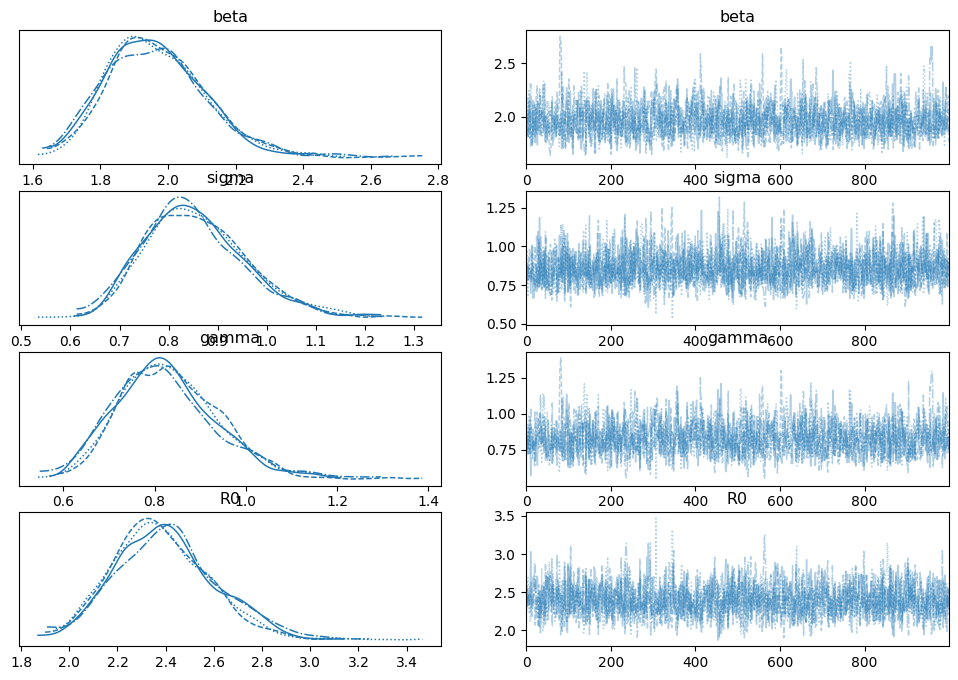

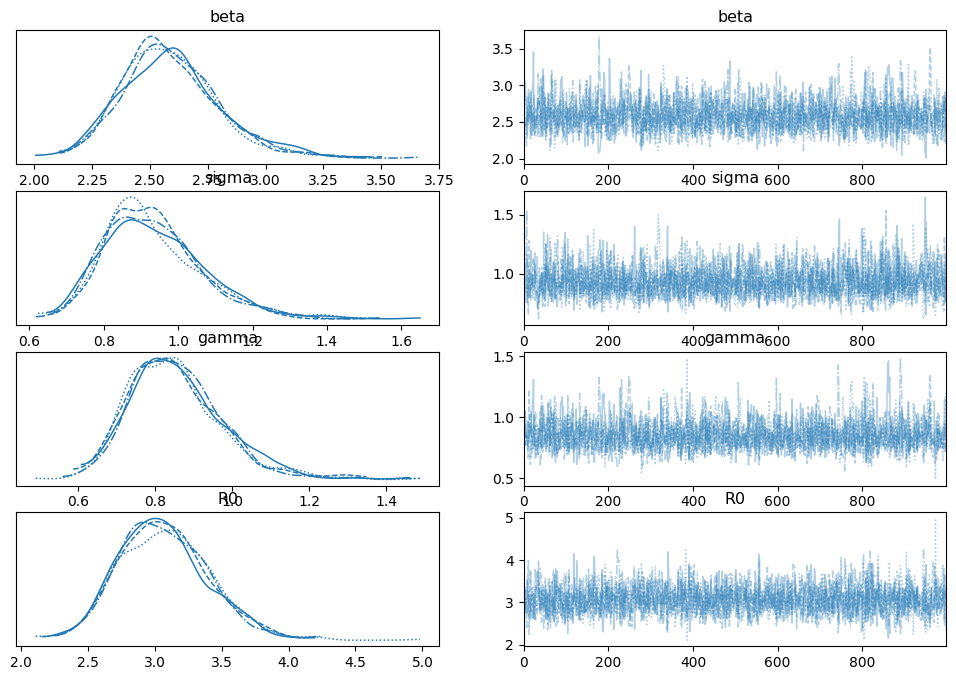

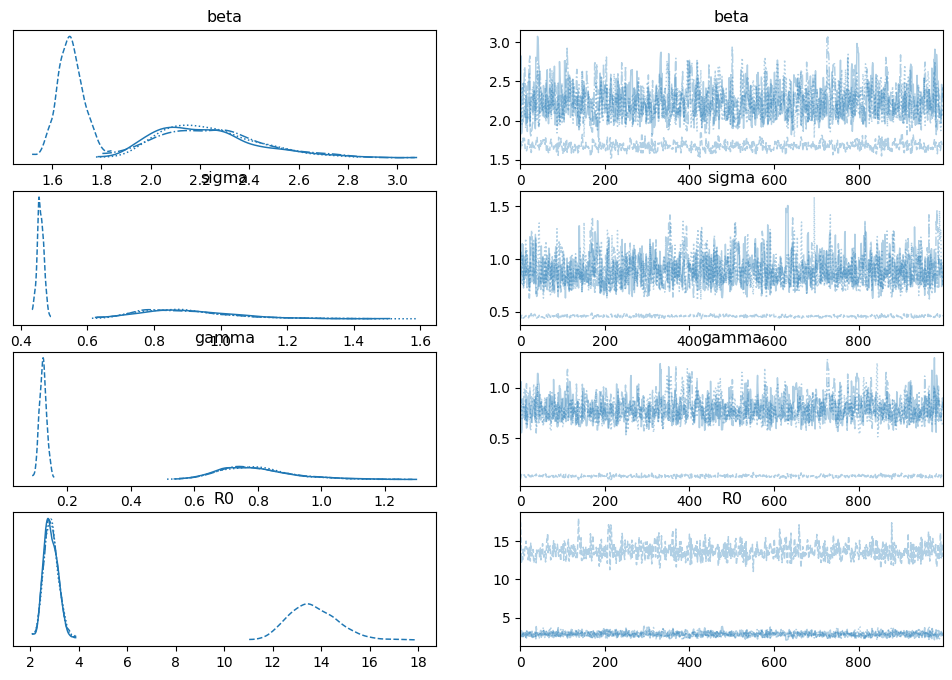

In [34]:
## trace plots
az.plot_trace(fit_seir_incidence_model, var_names=["beta", "sigma", "gamma", "R0"])
az.plot_trace(fit2, var_names=["beta", "sigma", "gamma", "R0"])
az.plot_trace(fit3, var_names=["beta", "sigma", "gamma", "R0"])
plt.show()

# Posterior Predictive Checks

In [35]:
seir_incidence_summary.filter(like="pred_incidence", axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
pred_incidence[1],12.5563,0.098951,6.03912,5.9304,4.0,12.0,24.0,3762.61,3723.75,1.000170
pred_incidence[2],21.1653,0.153319,9.42203,8.8956,8.0,20.0,38.0,3735.49,3704.44,1.000790
pred_incidence[3],33.2567,0.222517,13.90400,13.3434,14.0,31.0,59.0,3980.16,3668.04,1.001060
pred_incidence[4],52.4990,0.348352,21.77360,20.7564,22.0,50.0,92.0,3887.46,3970.36,1.000170
pred_incidence[5],82.5900,0.535292,33.06000,32.6172,36.0,79.0,142.0,3831.43,3845.56,0.999545
...,...,...,...,...,...,...,...,...,...,...
pred_incidence[92],0.0000,NaN,0.00000,0.0000,0.0,0.0,0.0,NaN,NaN,NaN
pred_incidence[93],0.0000,NaN,0.00000,0.0000,0.0,0.0,0.0,NaN,NaN,NaN
pred_incidence[94],0.0000,NaN,0.00000,0.0000,0.0,0.0,0.0,NaN,NaN,NaN
pred_incidence[95],0.0000,NaN,0.00000,0.0000,0.0,0.0,0.0,NaN,NaN,NaN


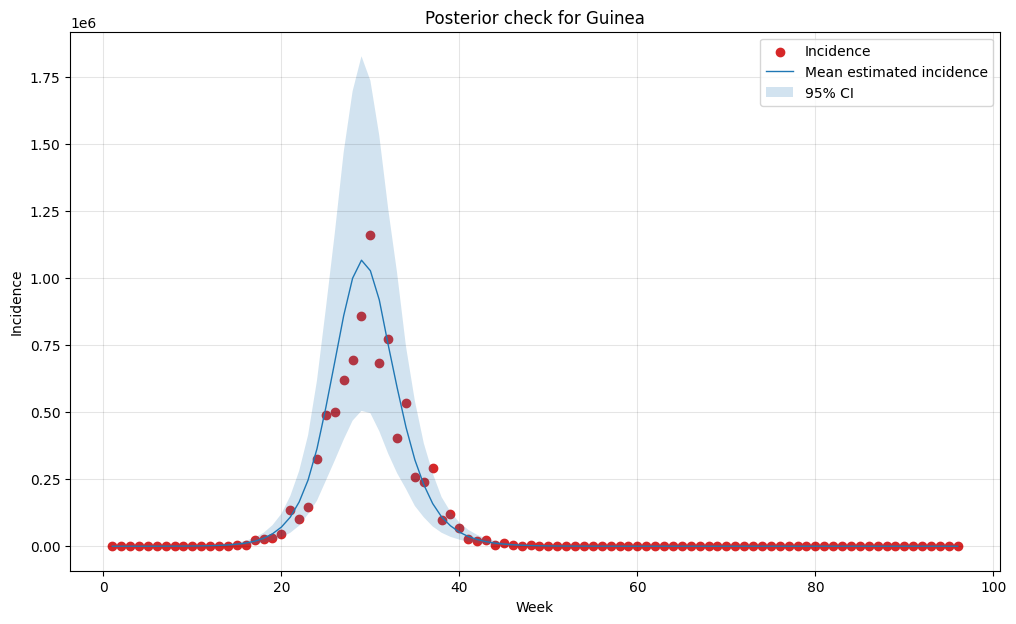

In [36]:
post_pred = pd.DataFrame(seir_incidence_summary.filter(like="pred_incidence", axis=0))
post_pred["t"] = range(1, T+1)
post_pred["incidence"] = list(cases1)
post_pred = post_pred.set_index("t")

plt.figure(figsize=(12, 7))
plt.grid(True, which='both', color = 'k', alpha = 0.1)
plt.title(f'Posterior check for Guinea')
plt.ylabel('Incidence')
plt.xlabel('Week')
plt.scatter(x = post_pred.index, y = post_pred.incidence, color = 'tab:red', label = "Incidence")
plt.plot(post_pred.Mean, color = 'tab:blue', linewidth= 1, label = "Mean estimated incidence")
plt.fill_between(x = post_pred.index, y1 = post_pred['5%'], y2 = post_pred['95%'], alpha=0.2, label="95% CI")
# plt.facecolor('white')
plt.legend(loc = "upper right")

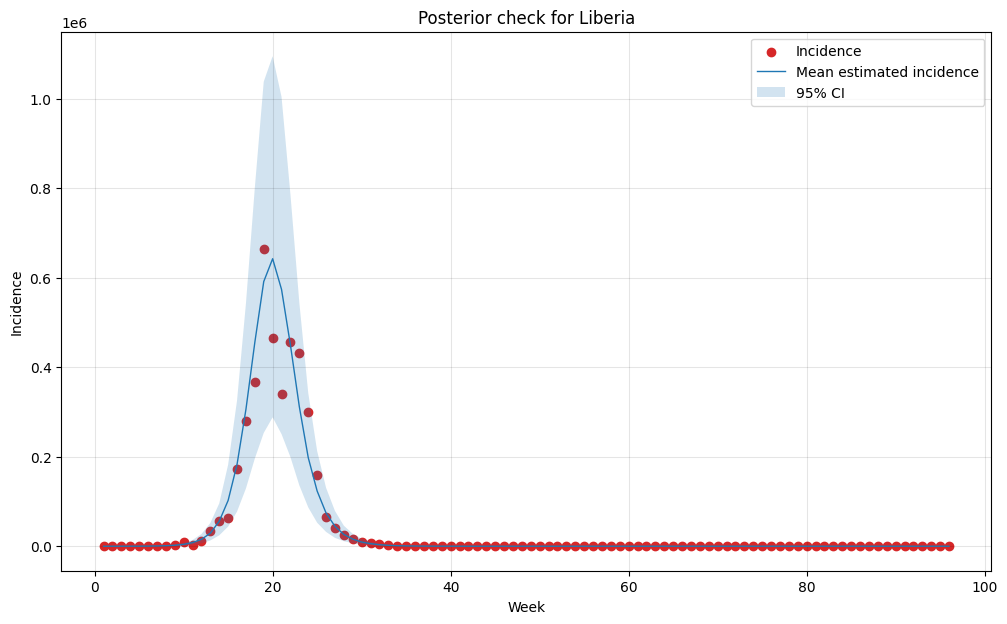

In [37]:
post_pred2 = pd.DataFrame(fit2_summary.filter(like="pred_incidence", axis=0))
post_pred2["t"] = range(1, T+1)
post_pred2["incidence"] = list(cases2)
post_pred2 = post_pred2.set_index("t")

plt.figure(figsize=(12, 7))
plt.grid(True, which='both', color = 'k', alpha = 0.1)
plt.title(f'Posterior check for Liberia')
plt.ylabel('Incidence')
plt.xlabel('Week')
plt.scatter(x = post_pred2.index, y = post_pred2.incidence, color = 'tab:red', label = "Incidence")
plt.plot(post_pred2.Mean, color = 'tab:blue', linewidth= 1, label = "Mean estimated incidence")
plt.fill_between(x = post_pred2.index, y1 = post_pred2['5%'], y2 = post_pred2['95%'], alpha=0.2, label="95% CI")
# plt.facecolor('white')
plt.legend(loc = "upper right")

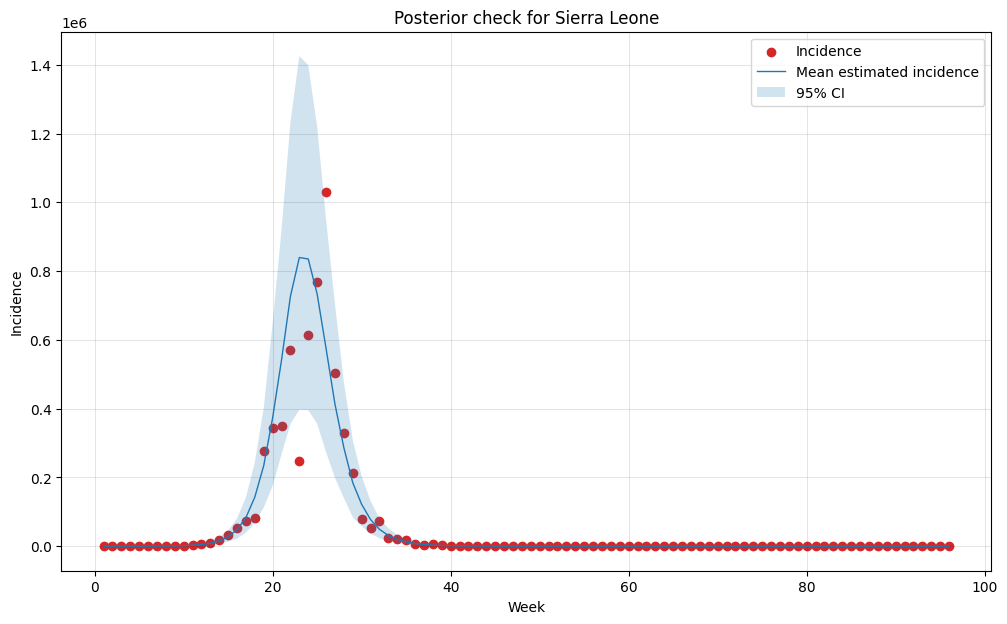

In [38]:
post_pred3 = pd.DataFrame(fit3_summary.filter(like="pred_incidence", axis=0))
post_pred3["t"] = range(1, T+1)
post_pred3["incidence"] = list(cases3)
post_pred3 = post_pred3.set_index("t")

plt.figure(figsize=(12, 7))
plt.grid(True, which='both', color = 'k', alpha = 0.1)
plt.title(f'Posterior check for Sierra Leone')
plt.ylabel('Incidence')
plt.xlabel('Week')
plt.scatter(x = post_pred3.index, y = post_pred3.incidence, color = 'tab:red', label = "Incidence")
plt.plot(post_pred3.Mean, color = 'tab:blue', linewidth= 1, label = "Mean estimated incidence")
plt.fill_between(x = post_pred3.index, y1 = post_pred3['5%'], y2 = post_pred3['95%'], alpha=0.2, label="95% CI")
# plt.facecolor('white')
plt.legend(loc = "upper right")

In [39]:
# Assuming `fit` is your CmdStanMCMC object from fitting the model
parameters1 = ["beta", "sigma", "recovery_time", "gamma", "incubation_period", "R0","phi"]

beta = np.array([0.3, 0.4, 0.35])*7  # Transmission rate (R0 = beta/gamma)
sigma = 1/8.5 *7       # 1/latent period (Ebola: ~10 days) Average value
gamma = 1/13 *7      # 1/infectious period (Ebola: ~7 days)
phi = 10           # Negative binomial dispersion parameter
alpha = 0.05*7
reporting_rate = 1 #0.8  # Proportion of cases reported
r = beta/gamma
rec = 1.0/gamma
incu = 1.0 / sigma

t1 = {'beta':beta[0],'sigma': sigma, 'gamma': gamma, 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[0], 'recovery_time':rec,
    'incubation_period': incu}

t2 = {'beta':beta[1],'sigma': sigma, 'gamma': gamma, 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[1], 'recovery_time':rec,
    'incubation_period': incu}

t3 = {'beta':beta[1],'sigma': sigma, 'gamma': gamma, 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[1], 'recovery_time':rec,
    'incubation_period': incu}

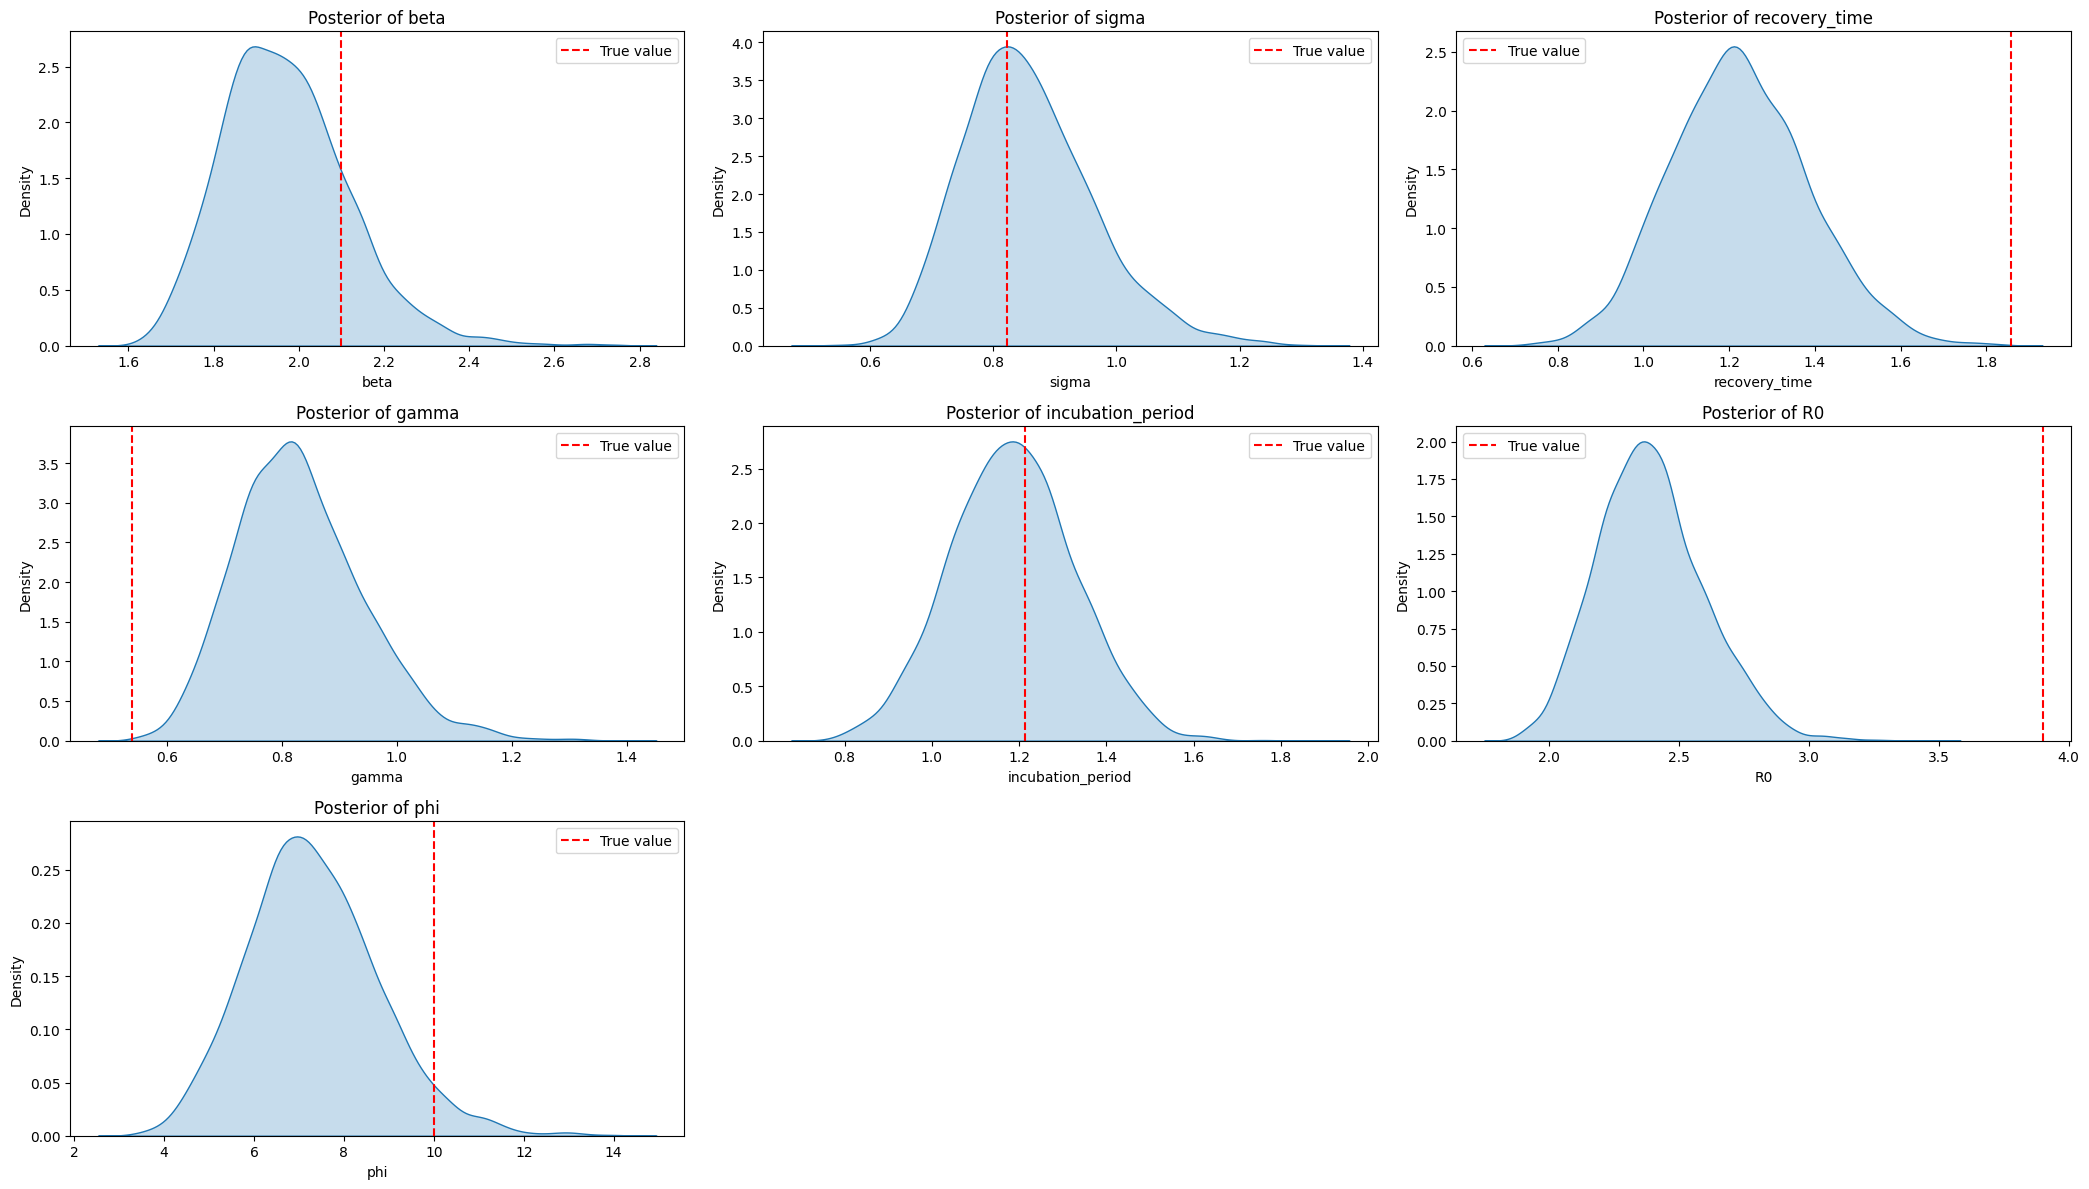

In [40]:
plot_posterior_kde_grid(fit_seir_incidence_model, parameters1, 3,t1, save = 'Checks_for_Guinea')

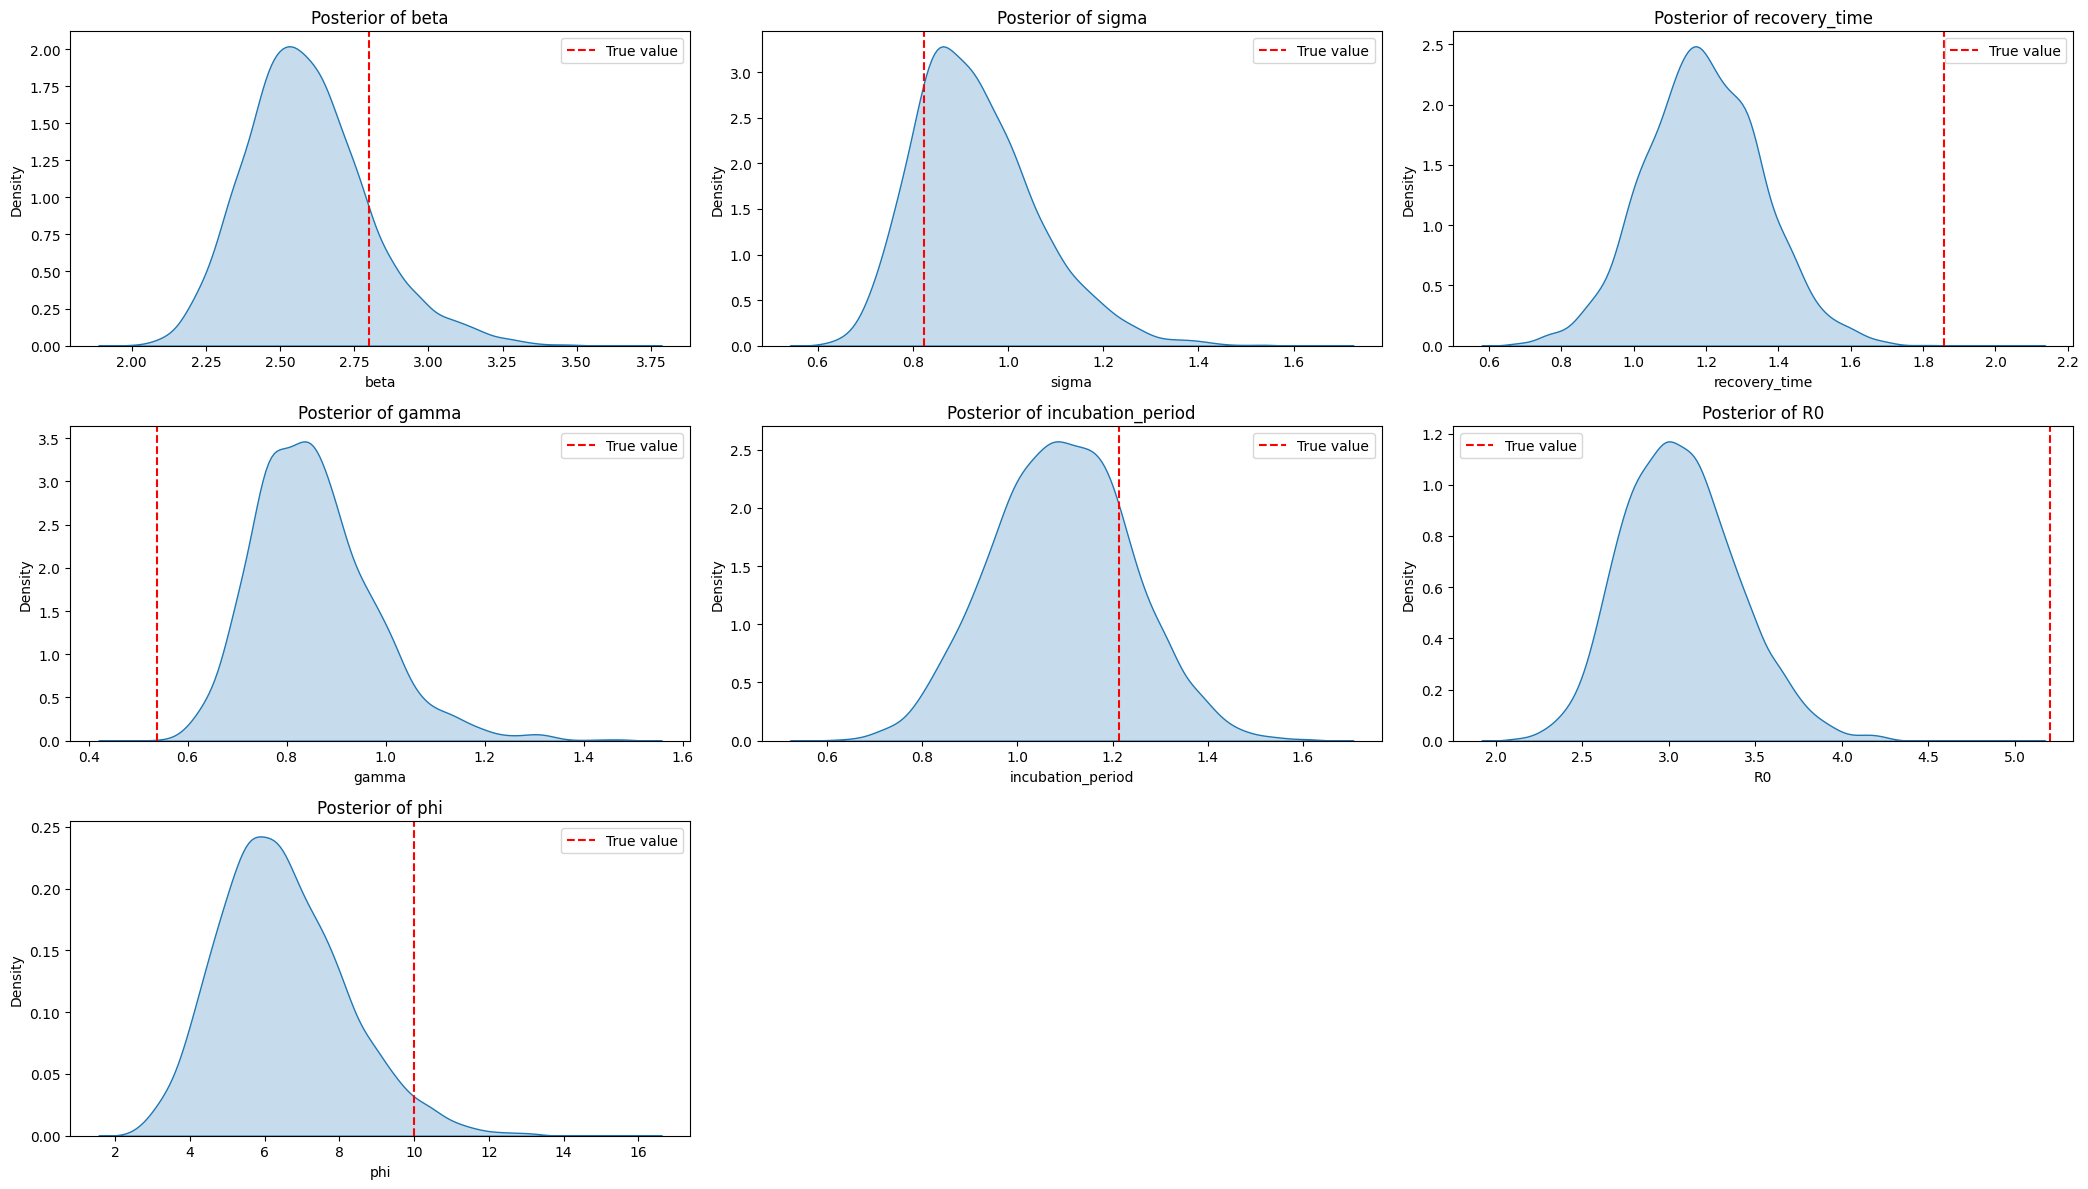

In [41]:
plot_posterior_kde_grid(fit2, parameters1, 3,t2, save = 'Checks_for_Liberia')

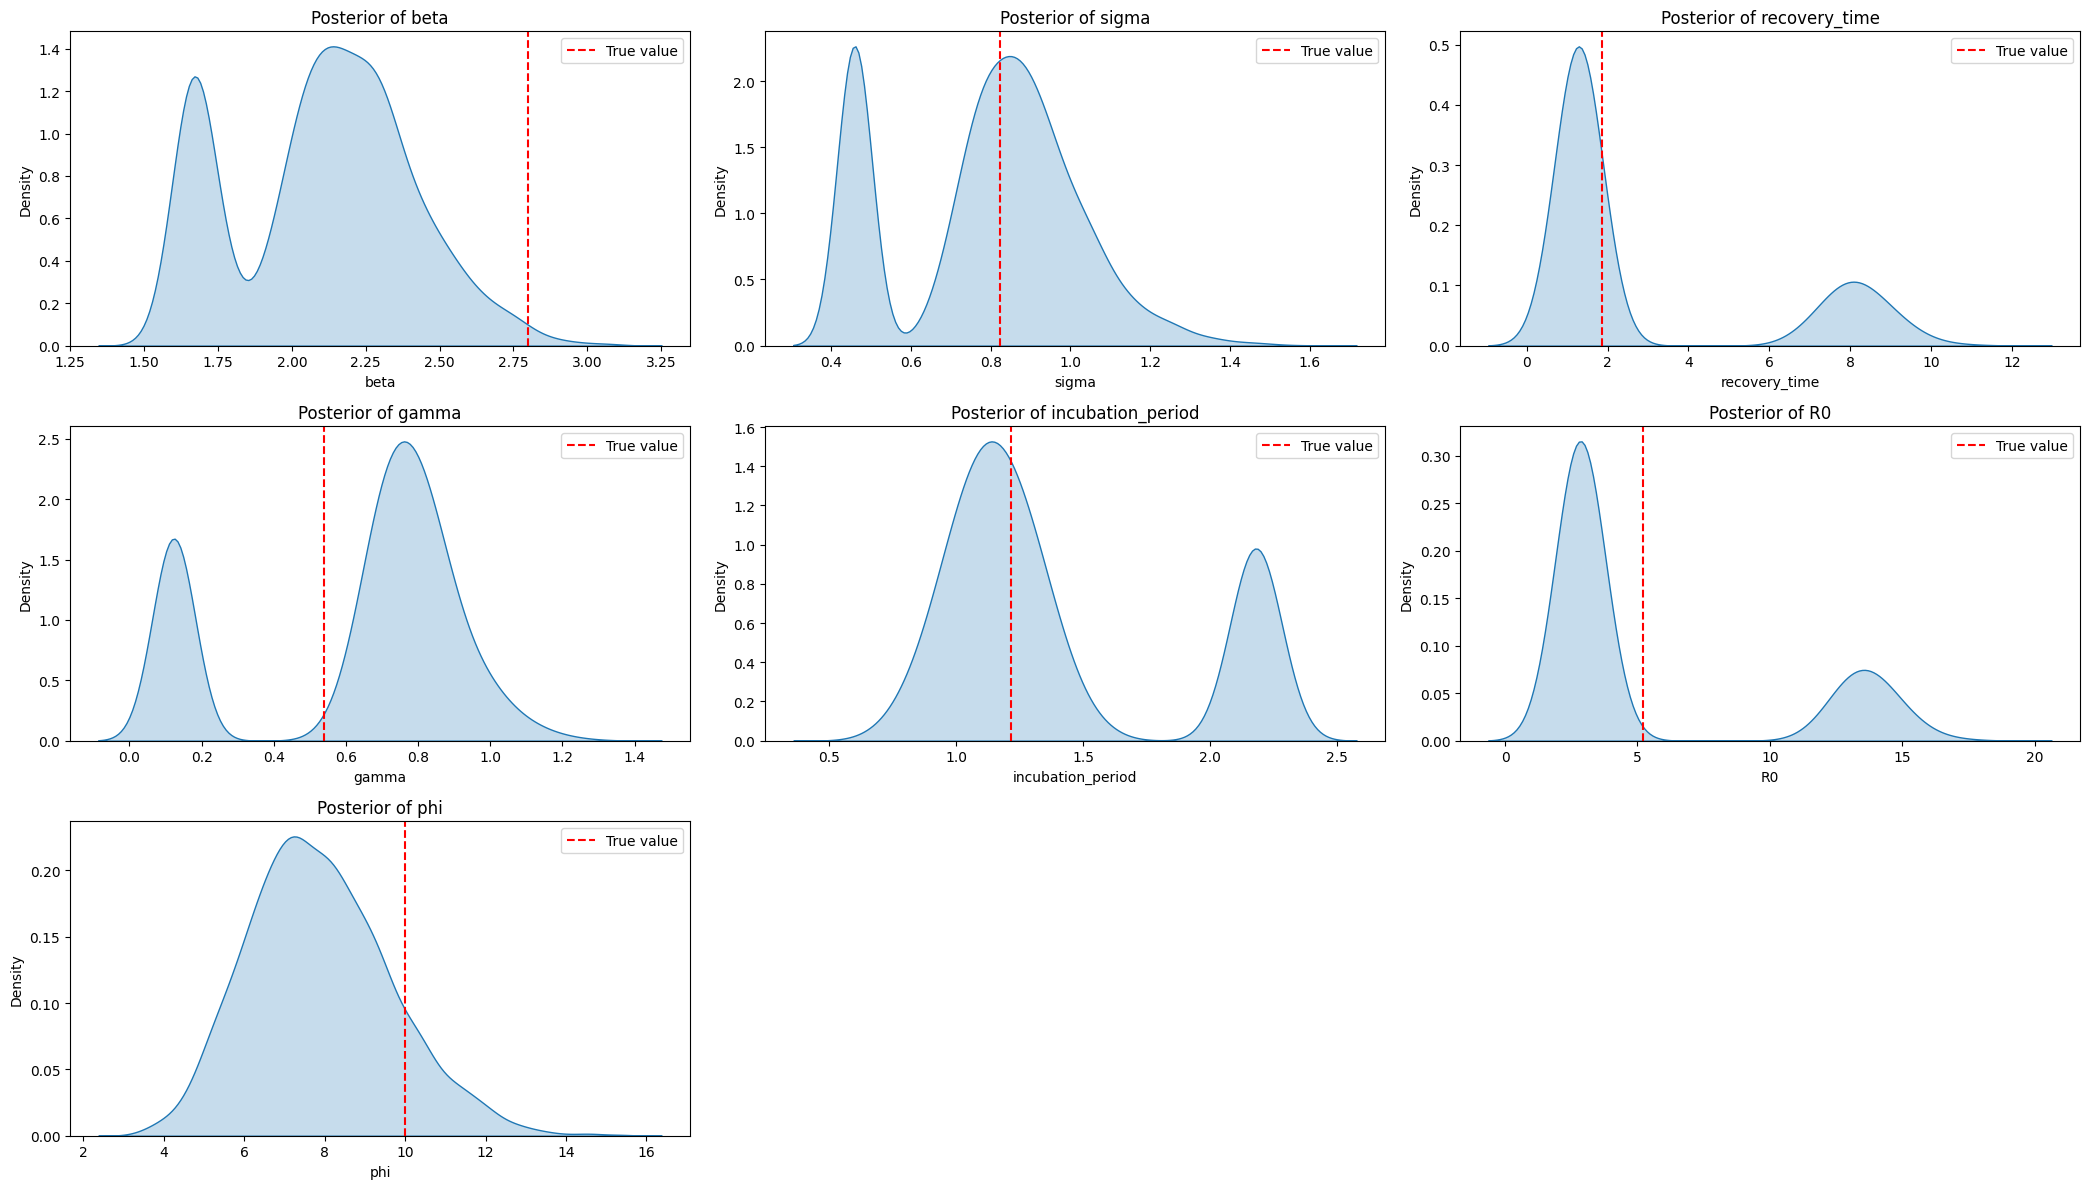

In [42]:
plot_posterior_kde_grid(fit3, parameters1, 3,t3, save = 'Checks_for_Sierra_Leone')

## Plot SEIR Compartments

In [43]:

def plot_compartment(fit, country_idx):
    # Time points and countries
    weeks = np.arange(fit.stan_variable('incidence').shape[1])  # Number of weeks
    countries = ['Guinea', 'Liberia', 'Sierra Leone']

    # Plot incidence (infectious) and reconstructed other compartments
    # for i in range(countries):
    # Create figure
    plt.figure(figsize=(12, 7))
    incidence = np.mean(fit.stan_variable('incidence'), axis=0)

    # Reconstruct approximate compartments (scaled by reporting rate)
    I = incidence
    R = np.cumsum(I) * np.mean(fit.stan_variable('gamma'))
    E = np.roll(I, 1) / np.mean(fit.stan_variable('sigma'))  # Exposed ~ delayed infectious
    # E[0] = 0
    S = N[country_idx] - E - I - R

    # Convert to fractions
    S_frac = S / N[country_idx]
    E_frac = E / N[country_idx]
    I_frac = I / N[country_idx]
    R_frac = R / N[country_idx]

    # Plot
    plt.plot(weeks, S_frac, 'b', label='Susceptible')
    plt.plot(weeks, E_frac, 'y', label='Exposed')
    plt.plot(weeks, I_frac, 'r', label='Infectious')
    plt.plot(weeks, R_frac, 'g', label='Recovered')

    # Formatting
    plt.title(f'{countries[country_idx]} (R0={np.mean(fit.stan_variable("R0")):.2f})')
    plt.ylabel('Fraction of Population')
    plt.grid(True, alpha=0.3)
    # ax.set_ylim(0, 1)

    plt.legend(loc='upper right')
    plt.xlabel('Weeks since outbreak start')
    # plt.tight_layout()
    plt.show()                                                                                      

In [44]:
# plot_compartment(fit_seir_incidence_model, country_idx=0)
# plot_compartment(fit2, country_idx=1)
# plot_compartment(fit3, country_idx=2)

# FITTING FOR 3 PATCHES

In [49]:
weekly = raw[['Guinea_Noise', 'Liberia_Noise', 'SierraLeone_Noise']]
weekly.head()

,Guinea_Noise,Liberia_Noise,SierraLeone_Noise
0,0,0,0
1,12,37,7
2,24,18,51
3,39,58,45
4,39,141,82


In [27]:

N = np.array([11.5e6, 4.5e6, 6.8e6]) 
# N = np.array([2e6, 1.5e6, 1e6])
# N = np.array([110000, 440000, 680000])
# Set the population size

# Define initial conditions
g0 = [N[0]-10, 10, 10, 0, 0]
l0 = [N[1]-10, 10, 10, 0, 0]
s0 = [N[2]-10, 10, 10, 0, 0]

ts = weekly.values.T
y0 = [g0, l0, s0]

beta = np.array([0.3, 0.4, 0.35])*7
sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7
gamma = np.array([1/13, 1/14, 1/13])*7

phi = 10           # Negative binomial dispersion parameter
alpha = 0.05*7
reporting_rate = 1  

# Make the data struture
seir_data = {
    'N_countries': 3,
    "n_weeks": len(ts[0]),
    'y0': y0,
    't0': 0,
    "t": np.arange(1, len(ts[0])+1),
    "N": N.astype(int),
    "cases": ts,
    'beta_values': beta,
    'sigma_values': sigma,
    'gamma_values': gamma,
    'reporting_rate': reporting_rate
}

multi_model = CmdStanModel(stan_file = 'stan files/mult.stan')

In [ ]:
fit_multi_model = multi_model.sample(data = seir_data,
                                     iter_sampling = 1000,
                                     parallel_chains=True,
                                     chains = 4,
                                     seed = 0)

chain 1 |          | 00:00 Status




chain 1 |▍         | 02:00 Status

In [ ]:
print(fit_multi_model.diagnose())

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

The following parameters had rank-normalized split R-hat greater than 1.01:
  beta[2], sigma[2], gamma[2], phi_inv, y[2,1,1], y[2,2,1], y[2,3,1], y[2,4,1], y[2,5,1], y[2,6,1], y[2,7,1], y[2,8,1], y[2,9,1], y[2,15,1], y[2,16,1], y[2,17,1], y[2,18,1], y[2,19,1], y[2,20,1], y[2,21,1], y[2,22,1], y[2,23,1], y[2,24,1], y[2,25,1], y[2,26,1], y[2,27,1], y[2,28,1], y[2,29,1], y[2,30,1], y[2,31,1], y[2,32,1], y[2,33,1], y[2,34,1], y[2,35,1], y[2,36,1], y[2,37,1], y[2,38,1], y[2,39,1], y[2,40,1], y[2,41,1], y[2,42,1], y[2,43,1], y[2,44,1], y[2,45,1], y[2,46,1], y[2,47,1], y[2,48,1], y[2,49,1], y[2,50,1], y[2,51,1], y[2,52,1], y[2,53,1], y[2,54,1], y[2,55,1], y[2,56,1], y[2,57,1

In [ ]:
multy_fit_summary = fit_multi_model.summary()
multy_fit_summary.filter(items=("beta[1]","beta[2]", "beta[3]", "sigma", "recovery_time",
                                 "gamma", "incubation_period", "R0[1]","R0[2]", "R0[3]",
                                   "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
beta[1],1.805080,0.004086,0.204337,0.197045,1.516110,1.780970,2.177770,2773.7600,2254.270,1.00334
beta[2],2.361470,0.066572,0.268103,0.202946,1.771130,2.392130,2.745440,21.0743,1927.110,1.12737
beta[3],2.155660,0.003075,0.162497,0.161685,1.915050,2.144130,2.441870,2955.2500,2326.280,1.00148
R0[1],3.377090,0.009805,0.581306,0.543180,2.549580,3.311840,4.397220,3497.8200,1854.500,1.00092
R0[2],4.366030,0.783338,2.503680,0.596769,2.769440,3.501400,11.228100,19.9000,2000.000,1.13031
R0[3],3.367960,0.007614,0.415538,0.405788,2.742910,3.334290,4.098510,3010.8600,2613.510,1.00020
phi,6.105750,0.102553,0.966830,0.912778,4.687160,6.017480,7.817170,76.9719,101.675,1.03716
phi_inv,0.167843,0.002276,0.026341,0.025377,0.127923,0.166183,0.213349,76.9713,101.675,1.03716


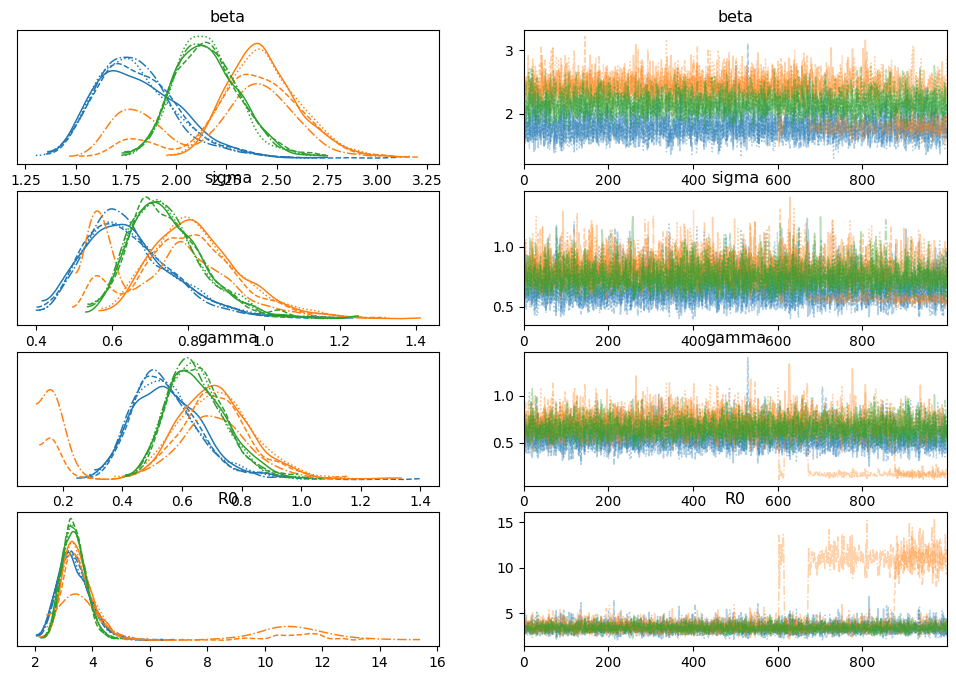

In [ ]:

az.plot_trace(fit_multi_model, var_names=["beta", "sigma", "gamma", "R0"])
plt.show()

# POSTERIOR PREDICTIVE CHECK

In [ ]:
# Get available variables
# Assuming `fit` is your CmdStanMCMC object from fitting the model
posterior_samples = fit_multi_model.draws_pd()  # returns a pandas DataFrame

beta = np.array([0.3, 0.4, 0.3])*7
sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7
gamma = np.array([1/13, 1/14, 1/13])*7   # 1/infectious period (Ebola: ~7 days)
phi = 10            # Negative binomial dispersion parameter
reporting_rate = 1
r = (beta/gamma)
rec = (1.0/gamma)
incu = (1.0 / sigma)

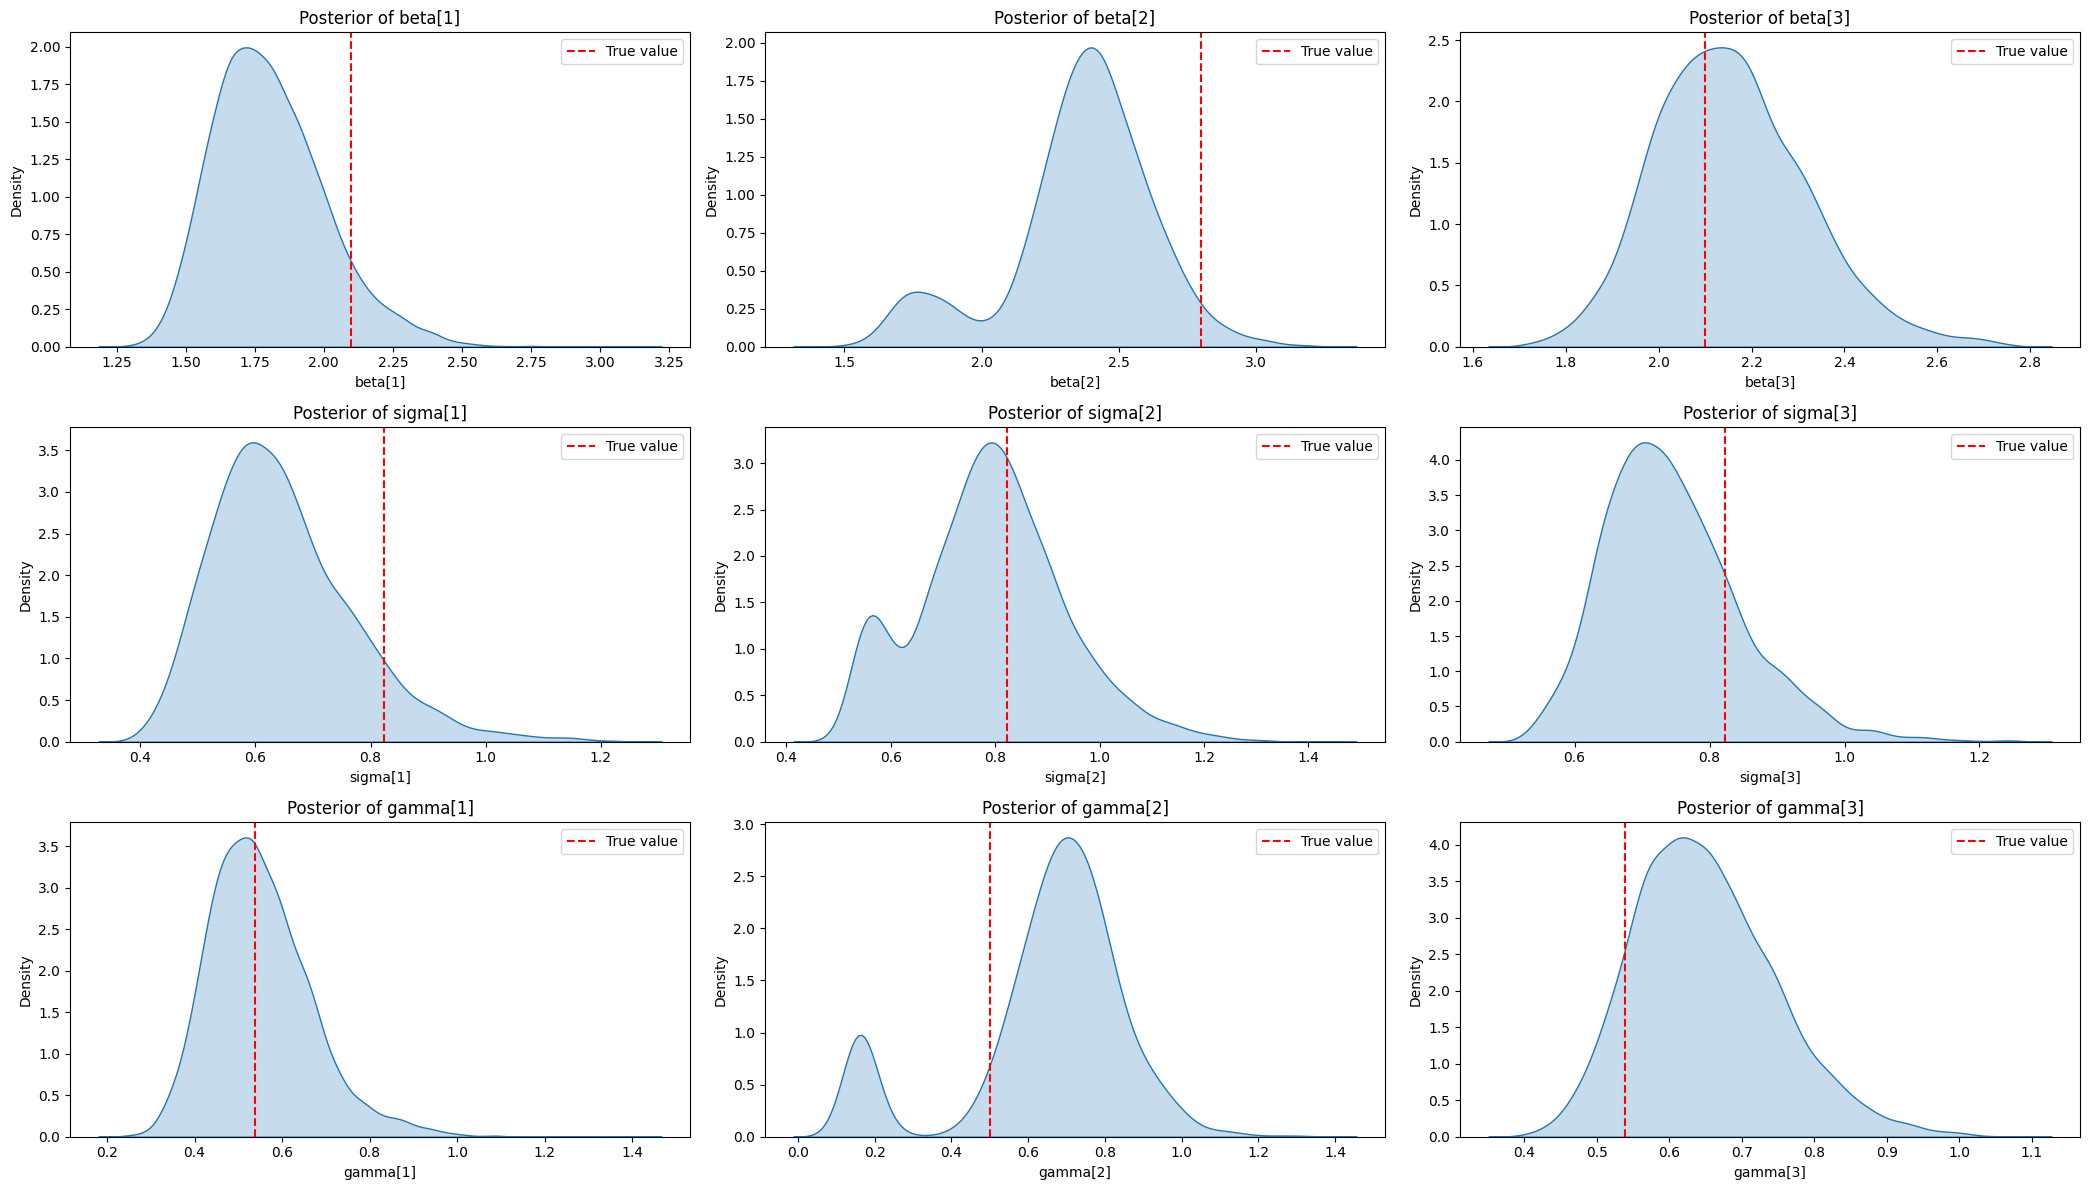

In [ ]:
parameters = ["beta[1]","beta[2]", "beta[3]", 
                "sigma[1]","sigma[2]","sigma[3]", 
                "gamma[1]","gamma[2]","gamma[3]"]
                
t = {'beta[1]': beta[0], 'beta[2]': beta[1], 'beta[3]': beta[2],
    'sigma[1]': sigma[0], 'sigma[2]': sigma[1], 'sigma[3]': sigma[2],   
    'gamma[1]': gamma[0], 'gamma[2]': gamma[1], 'gamma[3]': gamma[2],
    'phi': phi , 'reporting_rate':1}

plot_posterior_kde_grid(fit_multi_model, parameters=parameters, n_cols=3, true_values=t, save = 'Checks_for_betaGammaSigma')

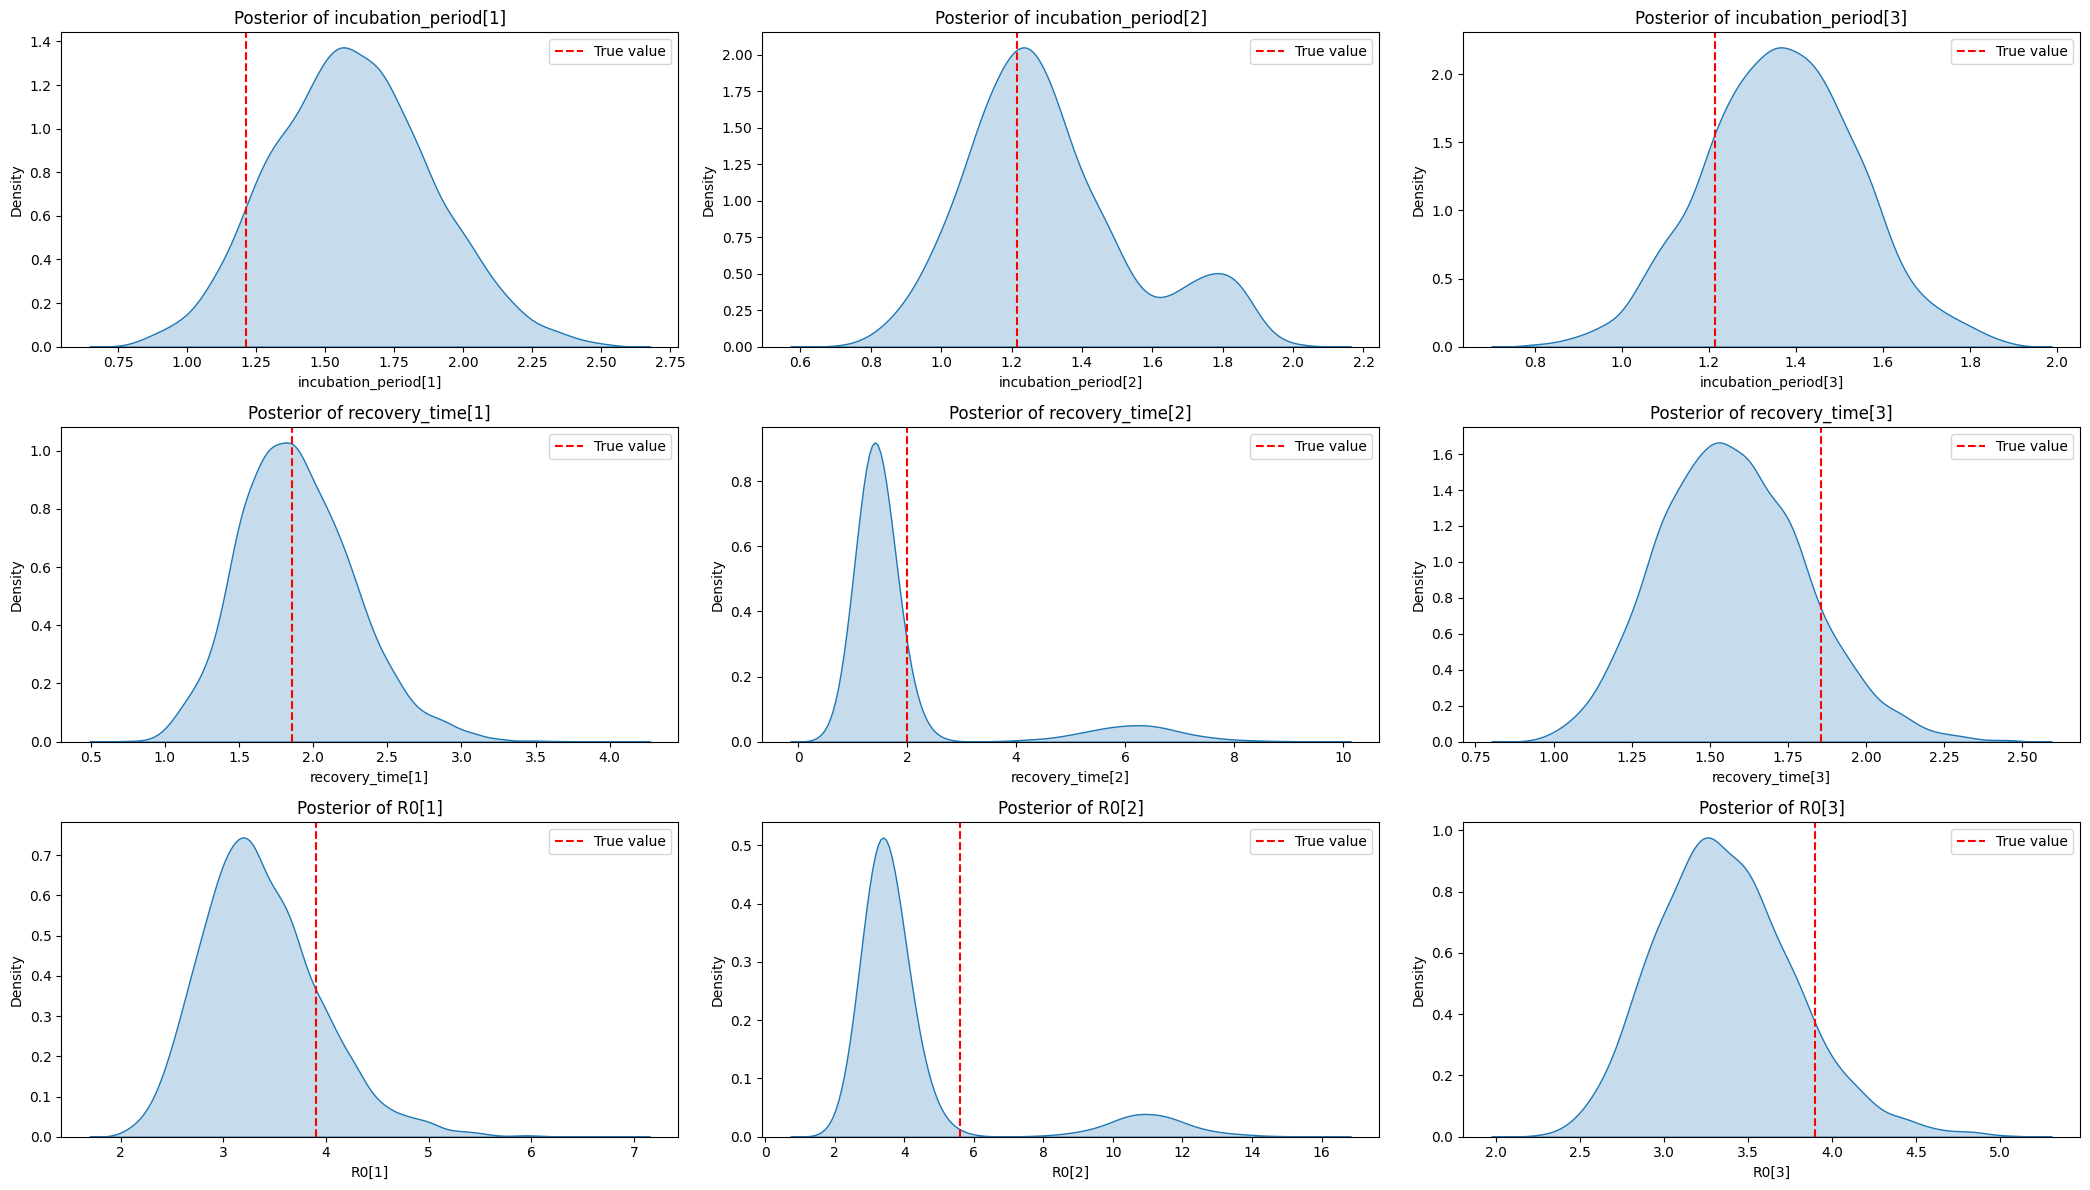

In [ ]:
parameters1 = ["incubation_period[1]","incubation_period[2]","incubation_period[3]", 
                "recovery_time[1]","recovery_time[2]","recovery_time[3]",
                "R0[1]","R0[2]", "R0[3]"]
t1 = {
    'R0[1]': r[0], 'R0[2]': r[1], 'R0[3]': r[2], 
    'recovery_time[1]':rec[0],
    'recovery_time[2]':rec[1],
    'recovery_time[3]':rec[2],
    'incubation_period[1]': incu[0],
    'incubation_period[2]': incu[1],
    'incubation_period[3]': incu[2]}


plot_posterior_kde_grid(fit_multi_model, parameters=parameters1, 
                        n_cols=3, true_values=t1, save = 'Checks_for_recoveryIncubationR0')

# PRIOR PREDICTIVE CHECK

In [ ]:

model_prior = CmdStanModel(stan_file = 'stan files/multi_patch_PRIOR.stan')
prior_check = model_prior.sample(data = seir_data,
                                     iter_sampling = 1000,
                                     chains = 4,
                                     seed = 0)

chain 1 |          | 00:00 Status

































































chain 1 |██████████| 02:09 Sampling completed                       
chain 2 |██████████| 02:09 Sampling completed                       
chain 3 |██████████| 02:09 Sampling completed                       
chain 4 |██████████| 02:09 Sampling completed                       

In [ ]:
import math
def plot_prior(model, param_names, boundary, ncols=3, 
               figsize_per_plot=(8, 7), 
               sharey=True, 
               legend_on_first=True):
    

    countries = ['Guinea','Liberia','Sierra Leone']
    n_params = len(param_names)
    nrows   = math.ceil(n_params / ncols)
    fig_w   = figsize_per_plot[0] * ncols
    fig_h   = figsize_per_plot[1] * nrows+1
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h))
    
    # flatten even if nrows or ncols == 1
    axes = np.array(axes).reshape(-1)
    
    for i, (ax, pname) in enumerate(zip(axes, param_names)):
        # pull samples: shape (n_samples, n_patches)
        samples = model.stan_variable(pname)
        df = pd.DataFrame(samples, columns=countries)
        
        # plot densities
        df.plot(kind='density', ax=ax, legend=False)
        ax.set_title(f'Prior predictive check for {pname}')
        ax.set_xlabel(pname)
        ax.grid(True)
        ax.axvline(x=boundary[i*2], color='r')
        ax.axvline(x=boundary[i*2+1], color='r')
    
    # hide any unused axes
    for ax in axes[n_params:]:
        ax.set_visible(False)

    
    # add legend if desired
    if legend_on_first and n_params > 0:
        axes[0].legend(countries, title='Patch')
    
    plt.tight_layout()
    return fig, axes


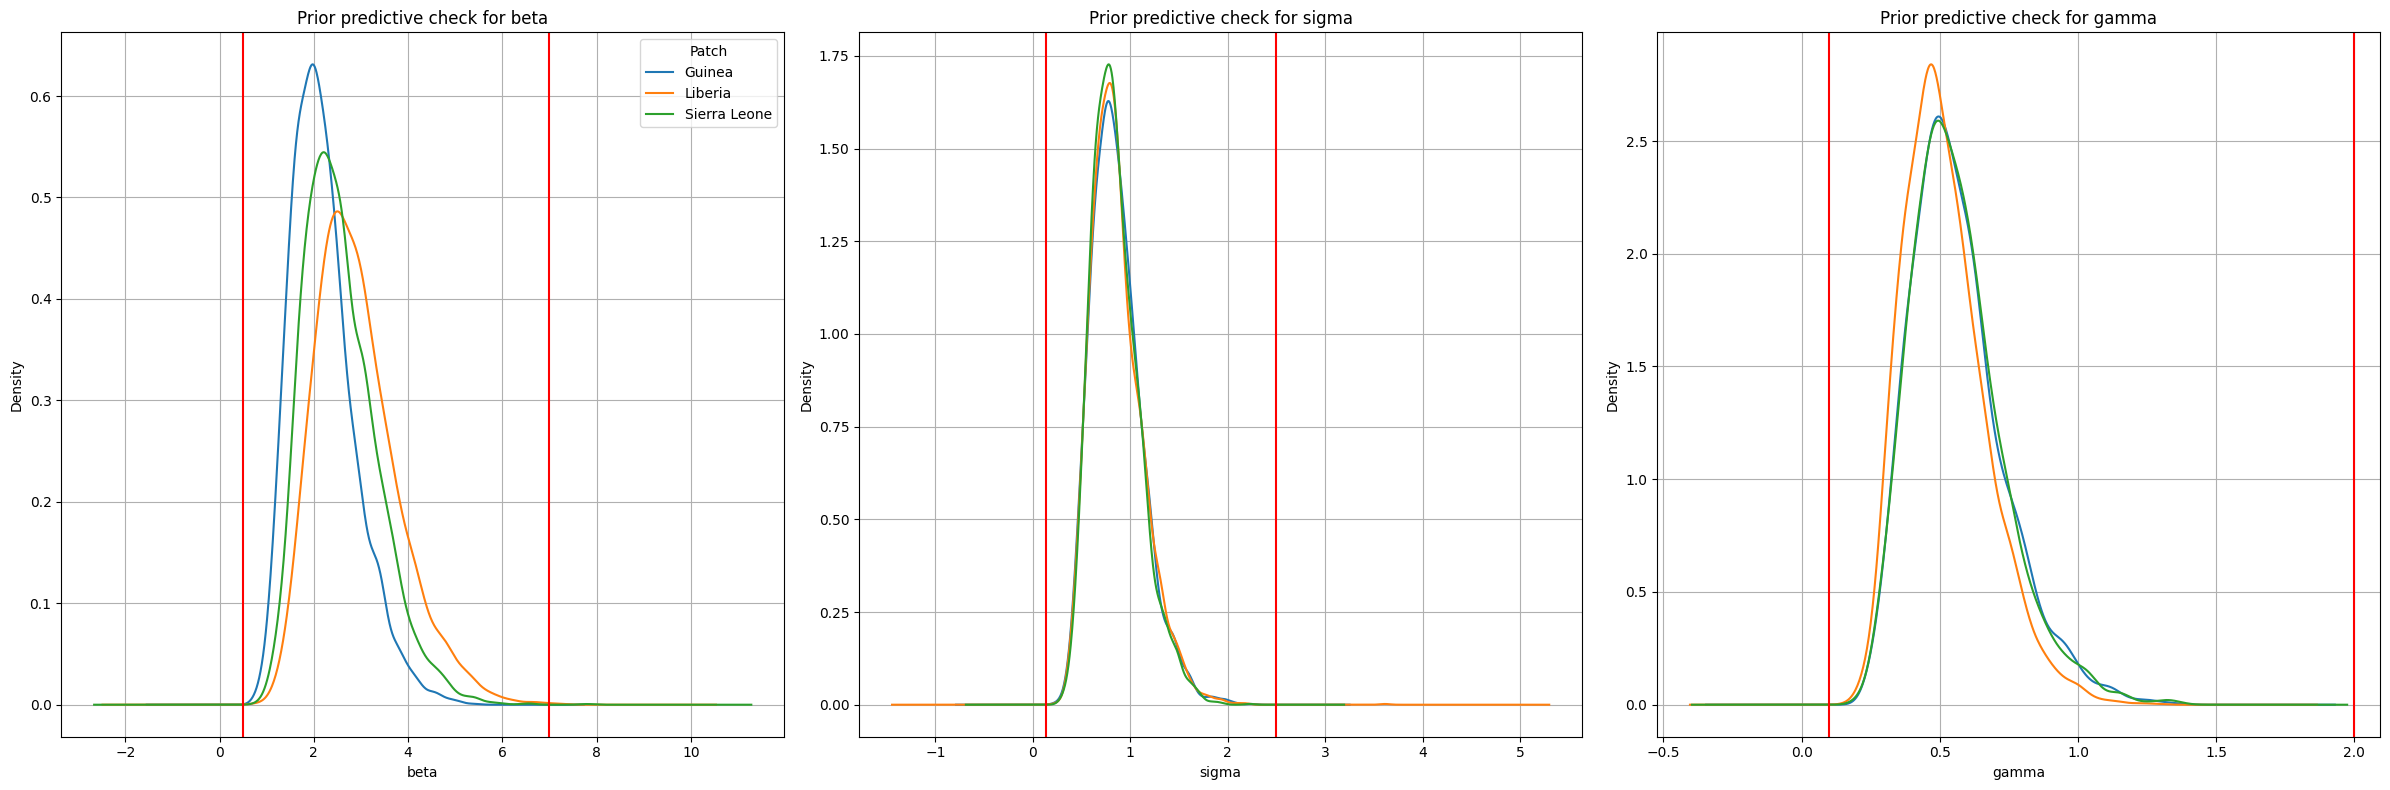

In [ ]:
params = ['beta','sigma','gamma']
boundaries = [0.5, 7, 0.14, 2.5, 0.1, 2.0]

# 5 parameters → grid of 2×3 (since ncols=3)
fig, axes = plot_prior(prior_check, params, boundary = boundaries, ncols=3)
plt.show()

In [ ]:
# infection_draws = prior_check.draws_pd("y")
# lines = plt.plot(range(1,15),
#                  infection_draws,
#                  color = "k", alpha = 0.1)
# plt.axhline(y=N[0], color='r', linestyle='--')
# plt.xlabel('Time')
# plt.ylabel('Number of infections')
# plt.show()

# R0

from sympy import *
init_printing()

# META POPULATION MODEL

$$
\begin{aligned}
S'_{p} &= -\sum_{j=1}^n \beta_{pj}\frac{S_{p}I_{j}}{N_j} \\
E'_{p} &= \sum_{j=1}^n \beta_{pj}\frac{S_{p}I_{j}}{N_j} - \sigma_{p} E_{p}\\
I'_{p} &= \sigma_{p} E_{p} - \gamma_{p} I_{p} \\
R'_{p} &= \gamma_{p} I_{p}
\end{aligned}
$$

Where:
- $ S_p, E_p, I_p, R_p $: Susceptible, Exposed, Infectious, and Recovered individuals in patch $ p $.
- $ N_p $: Total population for patch $ p $.
- $ \beta_{j} $: Transmission rate in patch $ p $ with individual contact from patch $j$.
- $ \sigma_{p} $: Rate of progression from Exposed to Infectious (inverse of the latent period).
- $ \gamma_{p} $: Recovery rate (inverse of the infectious period).

In [ ]:

# N = np.array([11.5e6, 4.5e6, 6.8e6]) 
# N = np.array([2e6, 1.5e6, 1e6])
N = np.array([110000, 440000, 680000])
# Set the population size

g0 = np.array([N[0]-10, 10, 10, 0])
l0 = np.array([N[1]-10, 10, 10, 0])
s0 = np.array([N[2]-10, 10, 10, 0])

y0 = np.concatenate([g0, l0, s0]).flatten()

ts = weekly.values.T

beta = np.array([0.3, 0.4, 0.35])*7
beta_ij = [np.array([0.3, 0.03, 0.035]), np.array([0.03, 0.4, 0.05]), np.array([0.035, 0.05, 0.35])]
sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7
gamma = np.array([1/13, 1/14, 1/13])*7

phi = 10           # Negative binomial dispersion parameter
alpha = 0.05*7
reporting_rate = 1  

# Make the data struture
seir_data = {
    'N_patches': 3,
    "n_weeks": len(ts[0]),
    'y0': y0,
    't0': 0,
    "t": np.arange(1, len(ts[0])+1),
    "N": N.astype(int),
    "cases": ts,
    'beta_data': beta_ij,
    'sigma_data': sigma,
    'gamma_data': gamma,
    'reporting_rate': reporting_rate
}

coupling_model = CmdStanModel(stan_file = 'stan files/metapopulation.stan')

In [ ]:
fit_coupling_model = coupling_model.sample(data = seir_data,
                                           iter_sampling = 1000,
                                           parallel_chains=True,
                                           chains = 4,
                                           seed = 0)

chain 1 |          | 00:00 Status





chain 4 |          | 00:00 Status

KeyboardInterrupt: 

In [45]:
coupling_summary = fit_coupling_model.summary()
coupling_summary.filter(items=("beta[1]","beta[2]", "beta[3]", "sigma[1]","sigma[2]","sigma[3]",
                                 "gamma[1]","gamma[2]", 'gamma[3]', 
                                "recovery_time[1]","recovery_time[2]", "recovery_time[3]",
                                 "incubation_period[1]",'incubation_period[2]', 'incubation_period[3]', 
                                 "R0[1]","R0[2]", "R0[3]", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma[1],2.250670,NaN,2.623170,0.797177,0.159353,1.078900,6.68551,NaN,NaN,NaN
sigma[2],0.828498,NaN,0.278434,0.338994,0.449780,0.856936,1.15034,NaN,NaN,NaN
sigma[3],1.744160,NaN,1.703140,1.759150,0.146174,1.348760,4.13296,NaN,NaN,NaN
gamma[1],1.559270,NaN,1.365760,1.316940,0.201936,1.227470,3.58019,NaN,NaN,NaN
gamma[2],1.522430,NaN,0.682178,0.566690,0.682116,1.421280,2.56505,NaN,NaN,NaN
gamma[3],1.777050,NaN,2.319150,0.143622,0.372077,0.497292,5.74153,NaN,NaN,NaN
recovery_time[1],1.958900,NaN,1.888710,1.348780,0.279315,1.302120,4.95206,NaN,NaN,NaN
recovery_time[2],0.815880,NaN,0.401798,0.242025,0.389856,0.703816,1.46603,NaN,NaN,NaN
recovery_time[3],1.740350,NaN,0.974198,0.682196,0.174170,2.049810,2.68761,NaN,NaN,NaN
incubation_period[1],2.079550,NaN,2.477290,0.692199,0.149577,0.946618,6.27537,NaN,NaN,NaN
